# Automated ML Pipeline — Generic, Data-Driven
## From Raw CSV → EDA → Feature Engineering → Model Training → Hyperparameter Tuning

This notebook implements a **fully automated, adaptive machine learning pipeline** that:
- Works on **any CSV dataset** regardless of domain
- Makes intelligent decisions at every stage based on data characteristics
- Provides **verbose debug explanations** for every decision via print statements
- Generates **plots, JSON artifacts, and explanations** at each step
- Handles outliers through **smoothing only** (never removal)
- Automatically selects, trains, and tunes the best models
- **No data leakage** — train/test split happens before any transformation

### How to use:
1. Set your CSV file path in the **Configuration** cell
2. Run the **Data Loading** cell
3. Review the column list and set your **TARGET** column
4. Run all remaining cells — the pipeline handles everything automatically

### Pipeline Stages:
| # | Stage | What Happens |
|---|-------|-------------|
| 1 | Configuration | Set file path, seed, output directory |
| 2 | Data Loading | Load CSV, preview, dtype summary |
| 3 | Column Overview | Print all columns for you to review |
| 4 | Target Selection | YOU set the target column here |
| 5 | Data Profiling | Nulls, duplicates, constants, ID-like, leakage detection |
| 6 | Auto-Clean | Drop bad columns, impute remaining nulls |
| 7 | Target Analysis & Split | Class balance, strategy decision, **train/test split** |
| 8 | Outlier Handling | Detect & smooth outliers (fit on train, apply to both) |
| 9 | Feature Type Handling | Encode categoricals (fit on train, apply to both), drop_first=False |
| 10 | EDA & Visualization | Distributions, correlations, statistical tests (training data only) |
| 11 | Feature Selection | RF + MI + Stat tests → consensus ranking, VIF with top-25% protection |
| 12 | Feature Scaling | Scaler fit on train, transform both |
| 13 | Model Shortlisting | Dynamic model selection, sample_weight for XGB/GB |
| 14 | Model Training | 5-fold CV with **f1_macro**, sample_weight where needed |
| 15 | Top-K Selection | Pick top 2 performers |
| 16 | Hyperparameter Tuning | Optuna 5-fold CV, consistent with training |
| 17 | Final Evaluation | Test set metrics (f1_macro + f1_weighted), confusion matrix |
| 18 | Save Artifacts | Model, scaler, encoder, transformers, feature names, metadata |

## Step 0 — Import Libraries

In [10]:
# ============================================================
# STEP 0: IMPORT ALL REQUIRED LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import copy
import warnings
from collections import Counter, OrderedDict
from datetime import datetime

from scipy import stats
from scipy.stats import skew, kurtosis

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     KFold, cross_val_score)
from sklearn.preprocessing import (LabelEncoder, StandardScaler, RobustScaler,
                                   MinMaxScaler, PowerTransformer, OrdinalEncoder)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, RandomForestRegressor,
                              GradientBoostingRegressor, ExtraTreesRegressor,
                              HistGradientBoostingClassifier,
                              HistGradientBoostingRegressor)
from sklearn.linear_model import (LogisticRegression, Ridge, Lasso,
                                  LinearRegression)
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, mean_squared_error,
                             mean_absolute_error, r2_score)
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# ─── Hardware Detection ─────────────────────────────────────────────
import multiprocessing
CPU_COUNT = multiprocessing.cpu_count()

GPU_AVAILABLE = False
GPU_NAME = 'None'
GPU_VRAM_MB = 0

# Check CUDA GPU via torch (most reliable)
try:
    import torch
    if torch.cuda.is_available():
        GPU_AVAILABLE = True
        GPU_NAME = torch.cuda.get_device_name(0)
        GPU_VRAM_MB = torch.cuda.get_device_properties(0).total_memory // (1024 * 1024)
except ImportError:
    pass

# Fallback: check if XGBoost was built with CUDA support
if not GPU_AVAILABLE:
    try:
        _test_xgb = xgb.XGBClassifier(device='cuda', n_estimators=1)
        _test_xgb.fit(np.array([[1,2],[3,4]]), np.array([0,1]))
        GPU_AVAILABLE = True
        GPU_NAME = 'CUDA device (detected via XGBoost)'
    except Exception:
        pass

print('=' * 70)
print('STEP 0: LIBRARY IMPORT & HARDWARE DETECTION')
print('=' * 70)
print('All libraries loaded successfully.')
print(f'  pandas     : {pd.__version__}')
print(f'  numpy      : {np.__version__}')
print(f'  sklearn    : {__import__("sklearn").__version__}')
print(f'  xgboost    : {xgb.__version__}')
print(f'  lightgbm   : {lgb.__version__}')
print(f'  optuna     : {optuna.__version__}')

print(f'\n--- Hardware ---')
print(f'  CPU cores  : {CPU_COUNT}')
if GPU_AVAILABLE:
    print(f'  GPU        : {GPU_NAME}')
    if GPU_VRAM_MB:
        print(f'  VRAM       : {GPU_VRAM_MB:,} MB')
    print(f'  XGBoost    : will use device="cuda"')
    print(f'  LightGBM   : will use device="gpu"')
else:
    print(f'  GPU        : Not available — using CPU only')
    print(f'  (Install PyTorch with CUDA or a CUDA toolkit to enable GPU acceleration)')

STEP 0: LIBRARY IMPORT & HARDWARE DETECTION
All libraries loaded successfully.
  pandas     : 2.3.3
  numpy      : 2.4.2
  sklearn    : 1.8.0
  xgboost    : 3.2.0
  lightgbm   : 4.6.0
  optuna     : 4.7.0

--- Hardware ---
  CPU cores  : 8
  GPU        : NVIDIA GeForce GTX 1650 Ti
  VRAM       : 4,095 MB
  XGBoost    : will use device="cuda"
  LightGBM   : will use device="gpu"


## Step 1 — Configuration
Set your CSV file path, random seed, and output directory below.

In [11]:
# ============================================================
# CONFIGURATION — EDIT THESE VALUES
# ============================================================
FILE_PATH   = r'data\synthetic_3000_dataset.csv'
RANDOM_SEED = 42
OUTPUT_DIR  = 'pipeline_output'

# ============================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

# Central pipeline state — JSON artifacts from every stage
PIPELINE_STATE = {}

print('=' * 70)
print('STEP 1: CONFIGURATION')
print('=' * 70)
print(f'  File path  : {FILE_PATH}')
print(f'  Random seed: {RANDOM_SEED}')
print(f'  Output dir : {OUTPUT_DIR}/')
print('  Configuration set successfully!')

STEP 1: CONFIGURATION
  File path  : data\synthetic_3000_dataset.csv
  Random seed: 42
  Output dir : pipeline_output/
  Configuration set successfully!


## Step 2 — Data Loading
Load the CSV file and inspect its basic properties.

In [12]:
print('=' * 70)
print('STEP 2: DATA LOADING')
print('=' * 70)

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f'File not found: {FILE_PATH}')

df_raw = pd.read_csv(FILE_PATH)
df = df_raw.copy()

print(f'\nData loaded successfully from: {FILE_PATH}')
print(f'  Rows   : {df.shape[0]:,}')
print(f'  Columns: {df.shape[1]}')
print(f'  Memory : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print(f'\nData Types Summary:')
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {dtype}: {count} columns')

print(f'\nFirst 5 rows:')
display(df.head())

PIPELINE_STATE['data_loading'] = {
    'rows': int(df.shape[0]),
    'cols': int(df.shape[1]),
    'dtypes': {str(k): int(v) for k, v in df.dtypes.value_counts().items()},
    'file': FILE_PATH
}
print(f'\nStep 2 complete.')

STEP 2: DATA LOADING

Data loaded successfully from: data\synthetic_3000_dataset.csv
  Rows   : 3,000
  Columns: 6375
  Memory : 146.05 MB

Data Types Summary:
  float64: 6373 columns
  object: 1 columns
  int64: 1 columns

First 5 rows:


,audspec_lengthL1norm_sma_range,audspec_lengthL1norm_sma_maxPos,audspec_lengthL1norm_sma_minPos,audspec_lengthL1norm_sma_quartile1,audspec_lengthL1norm_sma_quartile2,audspec_lengthL1norm_sma_quartile3,audspec_lengthL1norm_sma_iqr1-2,audspec_lengthL1norm_sma_iqr2-3,audspec_lengthL1norm_sma_iqr1-3,audspec_lengthL1norm_sma_percentile1.0,...,mfcc_sma_de[14]_peakMeanAbs,mfcc_sma_de[14]_peakMeanMeanDist,mfcc_sma_de[14]_peakMeanRel,mfcc_sma_de[14]_minRangeRel,mfcc_sma_de[14]_meanRisingSlope,mfcc_sma_de[14]_stddevRisingSlope,mfcc_sma_de[14]_meanFallingSlope,mfcc_sma_de[14]_stddevFallingSlope,cluster,sampling_rate
0,6.957549,1.056195,-0.001555,1.708190,2.452820,3.147237,0.748136,0.708211,1.438927,0.000931,...,1.907999,1.903635,-21.784765,0.682173,64.240589,56.959493,70.529901,78.011464,bipolar,44100
1,5.422767,0.819802,-0.010178,1.325081,1.923439,2.450572,0.577392,0.536125,1.122019,0.021815,...,1.497539,1.488262,-17.040206,0.517313,50.216519,44.530874,55.162168,60.976314,suicidal,44100
2,6.241342,0.936991,0.013580,1.518674,2.196110,2.818839,0.677129,0.634270,1.291670,0.007238,...,1.718944,1.736292,-19.616941,0.611327,57.788954,51.243619,63.449454,70.170268,normal,44100
3,6.203113,0.950505,-0.007018,1.518770,2.181174,2.816447,0.661628,0.620346,1.278666,0.030224,...,1.719122,1.697000,-19.499982,0.602563,57.495633,50.965355,63.138872,69.806449,depression,44100
4,6.290362,0.954612,-0.003401,1.545474,2.216301,2.850213,0.670728,0.617762,1.298028,0.021801,...,1.731799,1.729312,-19.754937,0.633981,58.216165,51.622184,63.950289,70.705469,normal,44100



Step 2 complete.


## Step 3 — Column Overview
Review **all columns** below. In the **next cell**, you will set which column is the target.

In [13]:
print('=' * 70)
print('STEP 3: COLUMN OVERVIEW')
print('=' * 70)

col_info = []
for i, col in enumerate(df.columns):
    dtype = str(df[col].dtype)
    nulls = int(df[col].isnull().sum())
    null_pct = round(nulls / len(df) * 100, 2)
    unique = int(df[col].nunique())
    sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    if isinstance(sample, str) and len(str(sample)) > 30:
        sample = str(sample)[:30] + '...'
    col_info.append({
        '#': i, 'Column': col, 'Type': dtype,
        'Nulls': nulls, 'Null%': null_pct,
        'Unique': unique, 'Sample': sample
    })

col_df = pd.DataFrame(col_info)
print(col_df.to_string(index=False))

print(f'\n>>> IMPORTANT: In the NEXT cell, set your TARGET column name.')
print(f'    Choose from the column names listed above.')

STEP 3: COLUMN OVERVIEW
   #                                                   Column    Type  Nulls  Null%  Unique                Sample
   0                           audspec_lengthL1norm_sma_range float64      0    0.0    3000              6.957549
   1                          audspec_lengthL1norm_sma_maxPos float64      0    0.0    3000              1.056195
   2                          audspec_lengthL1norm_sma_minPos float64      0    0.0    3000             -0.001555
   3                       audspec_lengthL1norm_sma_quartile1 float64      0    0.0    3000               1.70819
   4                       audspec_lengthL1norm_sma_quartile2 float64      0    0.0    3000               2.45282
   5                       audspec_lengthL1norm_sma_quartile3 float64      0    0.0    3000              3.147237
   6                          audspec_lengthL1norm_sma_iqr1-2 float64      0    0.0    3000              0.748136
   7                          audspec_lengthL1norm_sma_iqr2-3 fl

In [14]:
# ============================================================
#     DELETE UNWANTED COLUMNS (Optional)
# ============================================================
# List any columns you want to DROP before proceeding.
# Leave the list empty [] to skip deletion.

COLUMNS_TO_DROP = ['sampling_rate']   # <-- Add column names here, e.g. ['col1', 'col2']

# ============================================================

if COLUMNS_TO_DROP:
    missing = [c for c in COLUMNS_TO_DROP if c not in df.columns]
    if missing:
        print(f"[WARNING] These columns were not found and will be skipped: {missing}")
    valid_drops = [c for c in COLUMNS_TO_DROP if c in df.columns]
    if valid_drops:
        df = df.drop(columns=valid_drops)
        print(f"[OK] Dropped columns: {valid_drops}")
        print(f"     Remaining columns ({len(df.columns)}): {list(df.columns)}")
else:
    print("[SKIP] No columns dropped. 'df' is unchanged.")


[OK] Dropped columns: ['sampling_rate']
     Remaining columns (6374): ['audspec_lengthL1norm_sma_range', 'audspec_lengthL1norm_sma_maxPos', 'audspec_lengthL1norm_sma_minPos', 'audspec_lengthL1norm_sma_quartile1', 'audspec_lengthL1norm_sma_quartile2', 'audspec_lengthL1norm_sma_quartile3', 'audspec_lengthL1norm_sma_iqr1-2', 'audspec_lengthL1norm_sma_iqr2-3', 'audspec_lengthL1norm_sma_iqr1-3', 'audspec_lengthL1norm_sma_percentile1.0', 'audspec_lengthL1norm_sma_percentile99.0', 'audspec_lengthL1norm_sma_pctlrange0-1', 'audspec_lengthL1norm_sma_stddev', 'audspec_lengthL1norm_sma_skewness', 'audspec_lengthL1norm_sma_kurtosis', 'audspec_lengthL1norm_sma_meanSegLen', 'audspec_lengthL1norm_sma_maxSegLen', 'audspec_lengthL1norm_sma_minSegLen', 'audspec_lengthL1norm_sma_segLenStddev', 'audspec_lengthL1norm_sma_upleveltime25', 'audspec_lengthL1norm_sma_upleveltime50', 'audspec_lengthL1norm_sma_upleveltime75', 'audspec_lengthL1norm_sma_upleveltime90', 'audspec_lengthL1norm_sma_risetime', 'audspec_

## Step 4 — Target Column Selection
**Edit the cell below** — change `TARGET_COLUMN` to the column name you want to predict.

In [15]:
# ============================================================
#     SET YOUR TARGET COLUMN HERE
# ============================================================
TARGET_COLUMN = 'cluster'   # <-- CHANGE THIS to your target column name
# ============================================================

# --- Validation ---
if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{TARGET_COLUMN}' not found!\n"
        f"Available columns: {list(df.columns)}"
    )

print('=' * 70)
print('STEP 4: TARGET COLUMN SELECTION')
print('=' * 70)
print(f'  Target column : {TARGET_COLUMN}')
print(f'  Dtype         : {df[TARGET_COLUMN].dtype}')
print(f'  Unique values : {df[TARGET_COLUMN].nunique()}')
print(f'  Sample values : {df[TARGET_COLUMN].unique()[:10].tolist()}')
print(f'  Null count    : {df[TARGET_COLUMN].isnull().sum()}')

# --- Auto-detect task type ---
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() <= 20:
    TASK_TYPE = 'classification'
    print(f'\n  Auto-detected task: CLASSIFICATION ({df[TARGET_COLUMN].nunique()} classes)')
else:
    TASK_TYPE = 'regression'
    print(f'\n  Auto-detected task: REGRESSION (continuous target)')

PIPELINE_STATE['target'] = {
    'column': TARGET_COLUMN,
    'task_type': TASK_TYPE,
    'n_unique': int(df[TARGET_COLUMN].nunique())
}
print(f'\nStep 4 complete.')

STEP 4: TARGET COLUMN SELECTION
  Target column : cluster
  Dtype         : object
  Unique values : 6
  Sample values : ['bipolar', 'suicidal', 'normal', 'depression', 'stress', 'anxiety']
  Null count    : 0

  Auto-detected task: CLASSIFICATION (6 classes)

Step 4 complete.


## Step 5 — Data Profiling & Quality Audit
Automatically inspect data quality: nulls, duplicates, constant columns, ID-like columns, high-cardinality categoricals.

In [16]:
print('=' * 70)
print('STEP 5: DATA PROFILING & QUALITY AUDIT')
print('=' * 70)

columns_to_drop = []
drop_reasons = {}

# ─── 5.1 Null Value Analysis ────────────────────────────────────────
print('\n--- 5.1 Null Value Analysis ---')
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_cols = null_counts[null_counts > 0]

if len(null_cols) == 0:
    print('  No null values found in any column.')
else:
    print(f'  Found {len(null_cols)} columns with null values:')
    for col in null_cols.index:
        pct = null_pct[col]
        cnt = null_counts[col]
        print(f'    {col}: {cnt:,} nulls ({pct}%)')
        if pct > 50:
            columns_to_drop.append(col)
            drop_reasons[col] = f'Over {pct}% null values'
            print(f'      FLAGGED FOR REMOVAL (>50% null)')
        elif pct > 0:
            print(f'      Will be imputed in the cleaning step')

# ─── 5.2 Duplicate Rows ─────────────────────────────────────────────
print('\n--- 5.2 Duplicate Row Analysis ---')
n_dups = int(df.duplicated().sum())

if n_dups == 0:
    print('  No duplicate rows found.')
else:
    dup_pct = round(n_dups / len(df) * 100, 2)
    print(f'  Found {n_dups:,} duplicate rows ({dup_pct}%)')
    if dup_pct > 30:
        print(f'  High duplication detected! Keeping first occurrence only.')
        df = df.drop_duplicates(keep='first')
        print(f'  New shape after dedup: {df.shape}')
    else:
        print(f'  Duplication within acceptable range. Keeping all rows.')

# ─── 5.3 Constant Columns ───────────────────────────────────────────
print('\n--- 5.3 Constant Column Detection ---')
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    print(f'  Found {len(constant_cols)} constant column(s): {constant_cols}')
    for col in constant_cols:
        if col != TARGET_COLUMN and col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = 'Constant value — zero variance'
    print('  FLAGGED FOR REMOVAL (no predictive value)')
else:
    print('  No constant columns found.')

# ─── 5.4 ID-like Columns ────────────────────────────────────────────
print('\n--- 5.4 ID-like Column Detection ---')
id_cols = []
id_patterns = ['id', 'index', 'row_id', 'row_num', 'record_id', 'uid', 'uuid', 'pk']
for col in df.columns:
    if col == TARGET_COLUMN:
        continue
    col_dtype = df[col].dtype
    # Only flag integer or object columns with all-unique values as ID-like.
    # Float columns with unique values are normal continuous features — skip them.
    if df[col].nunique() == len(df) and col_dtype not in ['float64', 'float32']:
        id_cols.append(col)
    elif col.lower().strip('_') in id_patterns:
        id_cols.append(col)

if id_cols:
    print(f'  Found {len(id_cols)} ID-like column(s): {id_cols}')
    for col in id_cols:
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = 'ID-like column — unique per row'
    print('  FLAGGED FOR REMOVAL')
else:
    print('  No ID-like columns detected.')

# ─── 5.5 High-Cardinality Categoricals ──────────────────────────────
print('\n--- 5.5 High Cardinality Categorical Check ---')
cat_cols_check = df.select_dtypes(include='object').columns.tolist()
if TARGET_COLUMN in cat_cols_check:
    cat_cols_check.remove(TARGET_COLUMN)

high_card = []
for col in cat_cols_check:
    ratio = df[col].nunique() / len(df)
    if ratio > 0.5:
        high_card.append((col, df[col].nunique(), round(ratio * 100, 1)))

if high_card:
    print(f'  Found {len(high_card)} high-cardinality categorical column(s):')
    for col, nuniq, ratio in high_card:
        print(f'    {col}: {nuniq:,} unique values ({ratio}% of rows)')
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = f'High cardinality — {nuniq} unique values'
    print('  FLAGGED FOR REMOVAL (too many categories for encoding)')
else:
    print('  No high-cardinality categorical columns.')

# ─── 5.6 Target Leakage Detection ───────────────────────────────────
print('\n--- 5.6 Target Leakage Detection ---')
leakage_cols = []
for col in df.columns:
    if col == TARGET_COLUMN or col in columns_to_drop:
        continue
    # Check 1: perfect 1-to-1 mapping with the target
    if df[col].dtype == 'object' or df[col].nunique() <= df[TARGET_COLUMN].nunique():
        mapping = df[[TARGET_COLUMN, col]].drop_duplicates()
        if len(mapping) == df[TARGET_COLUMN].nunique() and mapping[col].nunique() == df[TARGET_COLUMN].nunique():
            leakage_cols.append(col)
            continue
    # Check 2: binary column that perfectly indicates a single target class
    #   e.g. target_Depression=1 iff profile='Depression' — one-hot leakage
    unique_vals = set(df[col].dropna().unique())
    if unique_vals == {0, 1} or unique_vals == {0.0, 1.0} or unique_vals == {True, False}:
        for cls in df[TARGET_COLUMN].unique():
            cls_mask = (df[TARGET_COLUMN] == cls)
            col_mask = (df[col] == 1)
            if cls_mask.equals(col_mask):
                leakage_cols.append(col)
                break

if leakage_cols:
    print(f'  Found {len(leakage_cols)} column(s) with perfect target mapping (LEAKAGE):')
    for col in leakage_cols:
        print(f'    [-] {col}: values map 1-to-1 with target "{TARGET_COLUMN}"')
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = f'Target leakage — perfect 1-to-1 mapping with {TARGET_COLUMN}'
    print('  FLAGGED FOR REMOVAL (model would cheat using these)')
else:
    print('  No target leakage detected.')

# ─── 5.7 Summary ────────────────────────────────────────────────────
print('\n--- 5.7 Profiling Summary ---')
if columns_to_drop:
    print(f'  Total columns flagged for removal: {len(columns_to_drop)}')
    for col in columns_to_drop:
        print(f'    [-] {col}: {drop_reasons.get(col, "flagged")}')
else:
    print('  No columns flagged for removal. All columns look good.')

PIPELINE_STATE['profiling'] = {
    'null_columns': {col: float(null_pct[col]) for col in null_cols.index} if len(null_cols) > 0 else {},
    'duplicates': n_dups,
    'constant_cols': constant_cols,
    'id_cols': id_cols,
    'high_cardinality': [x[0] for x in high_card],
    'flagged_for_removal': columns_to_drop,
    'drop_reasons': drop_reasons
}
print(f'\nStep 5 complete.')

STEP 5: DATA PROFILING & QUALITY AUDIT

--- 5.1 Null Value Analysis ---
  No null values found in any column.

--- 5.2 Duplicate Row Analysis ---
  No duplicate rows found.

--- 5.3 Constant Column Detection ---
  No constant columns found.

--- 5.4 ID-like Column Detection ---
  No ID-like columns detected.

--- 5.5 High Cardinality Categorical Check ---
  No high-cardinality categorical columns.

--- 5.6 Target Leakage Detection ---
  No target leakage detected.

--- 5.7 Profiling Summary ---
  No columns flagged for removal. All columns look good.

Step 5 complete.


## Step 6 — Auto-Clean
Drop flagged columns and impute any remaining null values.

In [17]:
print('=' * 70)
print('STEP 6: AUTO-CLEAN')
print('=' * 70)

# ─── 6.1 Drop flagged columns ───────────────────────────────────────
safe_to_drop = [c for c in columns_to_drop if c != TARGET_COLUMN]

if safe_to_drop:
    print(f'\nDropping {len(safe_to_drop)} column(s):')
    for col in safe_to_drop:
        print(f'  [-] {col} | Reason: {drop_reasons.get(col, "flagged")}')
    df = df.drop(columns=safe_to_drop)
    print(f'  Shape after drop: {df.shape}')
else:
    print('\n  No columns to drop. All columns retained.')

# ─── 6.2 Impute remaining nulls ────────────────────────────────────
print('\n--- 6.2 Null Imputation ---')
null_remaining = df.isnull().sum()
null_remaining = null_remaining[null_remaining > 0]

imputed_cols = []
if len(null_remaining) > 0:
    print(f'  Imputing {len(null_remaining)} columns with remaining nulls:')
    for col in null_remaining.index:
        if col == TARGET_COLUMN:
            before = len(df)
            df = df.dropna(subset=[TARGET_COLUMN])
            dropped = before - len(df)
            print(f'    {col} (target): Dropped {dropped} rows with null target')
        elif df[col].dtype in ['float64', 'int64', 'float32', 'int32']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            imputed_cols.append(col)
            print(f'    {col} (numeric): Filled with median = {median_val:.4f}')
        else:
            mode_vals = df[col].mode()
            mode_val = mode_vals.iloc[0] if len(mode_vals) > 0 else 'UNKNOWN'
            df[col] = df[col].fillna(mode_val)
            imputed_cols.append(col)
            print(f'    {col} (categorical): Filled with mode = {mode_val}')
else:
    print('  No remaining null values. No imputation needed.')

# ─── 6.3 Reset index (prevents misalignment after row removal) ──────
df = df.reset_index(drop=True)

print(f'\n  Clean dataset shape   : {df.shape}')
print(f'  Remaining null values : {df.isnull().sum().sum()}')
print(f'  Index reset to 0..{len(df)-1} (clean alignment)')

PIPELINE_STATE['auto_clean'] = {
    'columns_dropped': safe_to_drop,
    'imputed_columns': imputed_cols,
    'final_shape': list(df.shape)
}
print(f'\nStep 6 complete.')

STEP 6: AUTO-CLEAN

  No columns to drop. All columns retained.

--- 6.2 Null Imputation ---
  No remaining null values. No imputation needed.

  Clean dataset shape   : (3000, 6374)
  Remaining null values : 0
  Index reset to 0..2999 (clean alignment)

Step 6 complete.


## Step 7 — Target Analysis & Class Balance Check
Analyze the target variable: distribution, balance, and select the handling strategy.

STEP 7: TARGET ANALYSIS, CLASS BALANCE & TRAIN/TEST SPLIT

Class Distribution (6 classes):
  stress                              542 ( 18.07%) |#########
  bipolar                             533 ( 17.77%) |########
  anxiety                             515 ( 17.17%) |########
  suicidal                            478 ( 15.93%) |#######
  depression                          477 ( 15.90%) |#######
  normal                              455 ( 15.17%) |#######

Balance Check:
  Largest class  : stress (542)
  Smallest class : normal (455)
  Imbalance ratio: 1.19:1

  >> Dataset is BALANCED (ratio <= 1.5)
     Strategy: No class weights or resampling needed.


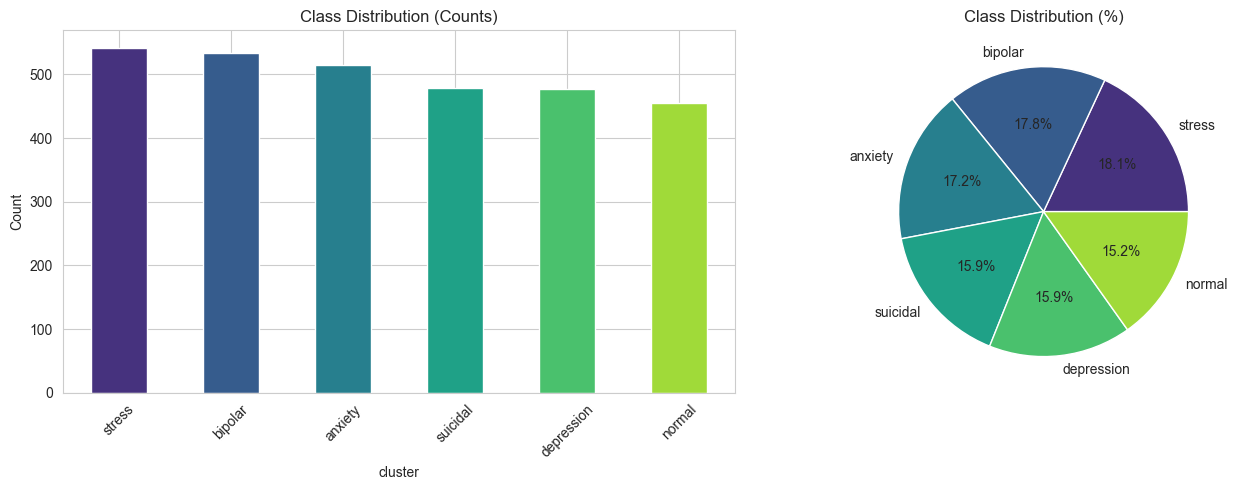


  Label encoding applied:
    anxiety -> 0
    bipolar -> 1
    depression -> 2
    normal -> 3
    stress -> 4
    suicidal -> 5

  Feature matrix shape: (3000, 6373)
  Target array length : 3000

--- Train/Test Split (BEFORE transformations — no data leakage) ---
  Stratified split applied (class proportions preserved).
  Train: 2,400 samples, 6373 features
  Test : 600 samples, 6373 features

  Train class distribution:
    anxiety: 412
    bipolar: 426
    depression: 382
    normal: 364
    stress: 434
    suicidal: 382

Step 7 complete.


In [18]:
print('=' * 70)
print('STEP 7: TARGET ANALYSIS, CLASS BALANCE & TRAIN/TEST SPLIT')
print('=' * 70)

if TASK_TYPE == 'classification':
    # ─── Class distribution ──────────────────────────────────────────
    class_counts = df[TARGET_COLUMN].value_counts()
    class_pct = (class_counts / len(df) * 100).round(2)
    n_classes = len(class_counts)

    print(f'\nClass Distribution ({n_classes} classes):')
    for cls in class_counts.index:
        count = class_counts[cls]
        pct = class_pct[cls]
        bar_len = int(pct / 2)
        bar = '#' * bar_len
        print(f'  {str(cls):<30} {count:>8,} ({pct:>6.2f}%) |{bar}')

    # ─── Balance check ───────────────────────────────────────────────
    max_count = class_counts.max()
    min_count = class_counts.min()
    imbalance_ratio = max_count / min_count

    print(f'\nBalance Check:')
    print(f'  Largest class  : {class_counts.idxmax()} ({max_count:,})')
    print(f'  Smallest class : {class_counts.idxmin()} ({min_count:,})')
    print(f'  Imbalance ratio: {imbalance_ratio:.2f}:1')

    # ─── Strategy decision ───────────────────────────────────────────
    if imbalance_ratio <= 1.5:
        BALANCE_STRATEGY = 'none'
        print(f'\n  >> Dataset is BALANCED (ratio <= 1.5)')
        print(f'     Strategy: No class weights or resampling needed.')
    elif imbalance_ratio <= 3.0:
        BALANCE_STRATEGY = 'class_weight'
        print(f'\n  >> Dataset is MODERATELY IMBALANCED (ratio {imbalance_ratio:.1f}:1)')
        print(f'     Strategy: Will use class_weight="balanced" in models.')
        print(f'     This adjusts the loss to penalize minority-class errors more.')
    else:
        BALANCE_STRATEGY = 'class_weight'
        print(f'\n  >> Dataset is HEAVILY IMBALANCED (ratio {imbalance_ratio:.1f}:1)')
        print(f'     Strategy: Will use class_weight="balanced" + stratified sampling.')
        print(f'     Consider collecting more data for minority classes if possible.')

    # ─── Plot ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = sns.color_palette('viridis', n_classes)
    class_counts.plot(kind='bar', ax=axes[0], color=colors)
    axes[0].set_title('Class Distribution (Counts)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    class_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
    axes[1].set_ylabel('')
    axes[1].set_title('Class Distribution (%)')

    plt.tight_layout()
    plt.show()

    # ─── Encode target ───────────────────────────────────────────────
    le = LabelEncoder()
    y = le.fit_transform(df[TARGET_COLUMN])
    class_names = le.classes_.tolist()
    print(f'\n  Label encoding applied:')
    for name, code in zip(class_names, le.transform(le.classes_)):
        print(f'    {name} -> {code}')

else:
    # ─── Regression target ───────────────────────────────────────────
    BALANCE_STRATEGY = 'none'
    le = None
    y = df[TARGET_COLUMN].values.astype(float)
    class_names = None
    n_classes = None
    imbalance_ratio = None

    print(f'\nTarget Distribution (Regression):')
    print(f'  Mean     : {y.mean():.4f}')
    print(f'  Std      : {y.std():.4f}')
    print(f'  Min      : {y.min():.4f}')
    print(f'  Max      : {y.max():.4f}')
    print(f'  Skewness : {stats.skew(y):.4f}')
    print(f'  Kurtosis : {stats.kurtosis(y):.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title('Target Distribution')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frequency')

    stats.probplot(y, plot=axes[1])
    axes[1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

# ─── Separate features from target ──────────────────────────────────
X_df = df.drop(columns=[TARGET_COLUMN])
print(f'\n  Feature matrix shape: {X_df.shape}')
print(f'  Target array length : {len(y)}')

# ─── TRAIN / TEST SPLIT (before ANY transformations) ────────────────
print(f'\n--- Train/Test Split (BEFORE transformations — no data leakage) ---')
if TASK_TYPE == 'classification':
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X_df, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    print(f'  Stratified split applied (class proportions preserved).')
else:
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X_df, y, test_size=0.2, random_state=RANDOM_SEED)
    print(f'  Random split applied.')

# Reset indices for clean alignment
X_train_df = X_train_df.reset_index(drop=True)
X_test_df = X_test_df.reset_index(drop=True)

print(f'  Train: {X_train_df.shape[0]:,} samples, {X_train_df.shape[1]} features')
print(f'  Test : {X_test_df.shape[0]:,} samples, {X_test_df.shape[1]} features')

if TASK_TYPE == 'classification':
    print(f'\n  Train class distribution:')
    train_counts = Counter(y_train)
    for cls_idx in sorted(train_counts.keys()):
        cls_name = class_names[cls_idx] if class_names else str(cls_idx)
        count = train_counts[cls_idx]
        print(f'    {cls_name}: {count:,}')

PIPELINE_STATE['target_analysis'] = {
    'task_type': TASK_TYPE,
    'balance_strategy': BALANCE_STRATEGY,
    'n_classes': int(n_classes) if n_classes else None,
    'imbalance_ratio': float(imbalance_ratio) if imbalance_ratio else None,
    'class_names': class_names,
    'train_size': int(X_train_df.shape[0]),
    'test_size': int(X_test_df.shape[0])
}
print(f'\nStep 7 complete.')

## Step 8 — Outlier Handling (Smoothing Only — No Removal!)
For each numeric column with outliers (detected on **training data only**), we test multiple
smoothing strategies and pick the one that best normalizes the distribution.
**No data points are ever removed.** Transformations are **fit on training data** and
applied identically to the test set (no data leakage).

Strategies tested per column:
- **Winsorizing** (cap to IQR bounds computed on training data)
- **Log1p transform** (for right-skewed, non-negative data)
- **Square root transform** (for moderate skew, non-negative data)
- **Yeo-Johnson transform** (works for any distribution, including negatives)

The strategy producing the lowest absolute skewness on training data wins.
All fitted transformers are saved for inference reproducibility.

STEP 8: OUTLIER HANDLING (SMOOTHING ONLY — TRAIN-FIT)
Strategy: Outliers are NEVER removed.
Transformations are FIT on training data only, then applied to both.
All fitted objects are saved for inference reproducibility.

Analyzing 6373 numeric columns for outliers (using training data)...

  audspec_lengthL1norm_sma_minPos:
    Outliers found  : 18 (0.75%)
    Original skew   : 0.044
    Strategies tested: winsorize, yeo-johnson
      winsorize       -> skew = 0.045
      yeo-johnson     -> skew = 0.000 <-- BEST
    Applied: yeo-johnson (new skew: 0.000)

  audspec_lengthL1norm_sma_percentile1.0:
    Outliers found  : 20 (0.83%)
    Original skew   : 0.134
    Strategies tested: winsorize, yeo-johnson
      winsorize       -> skew = 0.107
      yeo-johnson     -> skew = 0.000 <-- BEST
    Applied: yeo-johnson (new skew: 0.000)

  audspec_lengthL1norm_sma_upleveltime75:
    Outliers found  : 19 (0.79%)
    Original skew   : 0.049
    Strategies tested: winsorize, log1p, sqrt, yeo-johns

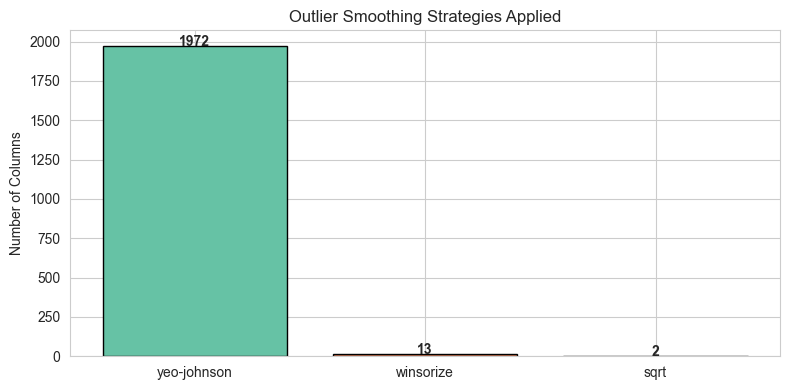


Step 8 complete.


In [19]:
print('=' * 70)
print('STEP 8: OUTLIER HANDLING (SMOOTHING ONLY — TRAIN-FIT)')
print('=' * 70)
print('Strategy: Outliers are NEVER removed.')
print('Transformations are FIT on training data only, then applied to both.')
print('All fitted objects are saved for inference reproducibility.\n')

numeric_cols = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
outlier_report = {}
transformations_applied = {}
outlier_transformers = {}  # Save fitted objects for inference

print(f'Analyzing {len(numeric_cols)} numeric columns for outliers (using training data)...\n')

for col in numeric_cols:
    train_vals = X_train_df[col].dropna()
    if len(train_vals) == 0:
        continue

    # Skip binary/one-hot columns — smoothing a 0/1 column is meaningless
    unique_vals = set(train_vals.unique())
    if unique_vals.issubset({0, 1, 0.0, 1.0}):
        continue

    # Compute IQR bounds on TRAINING data only
    Q1 = train_vals.quantile(0.25)
    Q3 = train_vals.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = int(((train_vals < lower_bound) | (train_vals > upper_bound)).sum())
    outlier_pct = round(n_outliers / len(train_vals) * 100, 2)

    if n_outliers == 0:
        continue

    original_skew = float(stats.skew(train_vals))
    all_non_negative = (train_vals >= 0).all()

    # Test multiple smoothing strategies on TRAINING data
    candidates = {}

    # 1. Winsorizing (capping to IQR bounds from training)
    capped = train_vals.clip(lower=lower_bound, upper=upper_bound)
    candidates['winsorize'] = abs(float(stats.skew(capped)))

    # 2. Log1p transform (only for non-negative data)
    if all_non_negative:
        log_vals = np.log1p(train_vals)
        candidates['log1p'] = abs(float(stats.skew(log_vals)))

    # 3. Square root transform (only for non-negative data)
    if all_non_negative:
        sqrt_vals = np.sqrt(train_vals)
        candidates['sqrt'] = abs(float(stats.skew(sqrt_vals)))

    # 4. Yeo-Johnson power transform (works for any distribution)
    try:
        pt = PowerTransformer(method='yeo-johnson')
        pt.fit(train_vals.values.reshape(-1, 1))  # FIT on train only
        yj_vals = pt.transform(train_vals.values.reshape(-1, 1)).flatten()
        candidates['yeo-johnson'] = abs(float(stats.skew(yj_vals)))
    except Exception:
        pt = None

    if not candidates:
        continue

    # Pick strategy with lowest absolute skewness on training data
    best_strategy = min(candidates, key=candidates.get)
    best_skew = candidates[best_strategy]

    # Apply the winning strategy to BOTH train and test
    if best_strategy == 'winsorize':
        X_train_df[col] = X_train_df[col].clip(lower=lower_bound, upper=upper_bound)
        X_test_df[col] = X_test_df[col].clip(lower=lower_bound, upper=upper_bound)
        outlier_transformers[col] = {
            'strategy': 'winsorize', 'lower': float(lower_bound), 'upper': float(upper_bound)
        }
    elif best_strategy == 'log1p':
        X_train_df[col] = np.log1p(X_train_df[col].clip(lower=0))
        X_test_df[col] = np.log1p(X_test_df[col].clip(lower=0))
        outlier_transformers[col] = {'strategy': 'log1p'}
    elif best_strategy == 'sqrt':
        X_train_df[col] = np.sqrt(X_train_df[col].clip(lower=0))
        X_test_df[col] = np.sqrt(X_test_df[col].clip(lower=0))
        outlier_transformers[col] = {'strategy': 'sqrt'}
    elif best_strategy == 'yeo-johnson' and pt is not None:
        X_train_df[col] = pt.transform(X_train_df[col].values.reshape(-1, 1)).flatten()
        X_test_df[col] = pt.transform(X_test_df[col].values.reshape(-1, 1)).flatten()
        outlier_transformers[col] = {'strategy': 'yeo-johnson', 'fitted_pt': pt}

    transformations_applied[col] = best_strategy
    outlier_report[col] = {
        'n_outliers': n_outliers,
        'outlier_pct': outlier_pct,
        'original_skewness': round(original_skew, 4),
        'strategy_applied': best_strategy,
        'new_skewness': round(best_skew, 4),
        'candidates_tested': {k: round(v, 4) for k, v in candidates.items()}
    }

    print(f'  {col}:')
    print(f'    Outliers found  : {n_outliers} ({outlier_pct}%)')
    print(f'    Original skew   : {original_skew:.3f}')
    print(f'    Strategies tested: {", ".join(candidates.keys())}')
    for strat, sk in candidates.items():
        marker = ' <-- BEST' if strat == best_strategy else ''
        print(f'      {strat:<15} -> skew = {sk:.3f}{marker}')
    print(f'    Applied: {best_strategy} (new skew: {best_skew:.3f})')
    print()

# ─── Summary ─────────────────────────────────────────────────────────
if not outlier_report:
    print('No significant outliers detected in any column. Data looks clean.')
else:
    strategies_used = Counter(transformations_applied.values())
    print(f'--- Outlier Handling Summary ---')
    print(f'  Columns with outliers treated: {len(outlier_report)}')
    print(f'  Strategies breakdown:')
    for strat, count in strategies_used.most_common():
        print(f'    {strat}: {count} columns')
    print(f'  All transformers saved for inference ({len(outlier_transformers)} columns)')

    fig, ax = plt.subplots(figsize=(8, 4))
    strat_names = list(strategies_used.keys())
    strat_counts = list(strategies_used.values())
    ax.bar(strat_names, strat_counts, color=sns.color_palette('Set2', len(strat_names)),
           edgecolor='black')
    ax.set_title('Outlier Smoothing Strategies Applied')
    ax.set_ylabel('Number of Columns')
    for i, (name, cnt) in enumerate(zip(strat_names, strat_counts)):
        ax.text(i, cnt + 0.1, str(cnt), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

PIPELINE_STATE['outlier_handling'] = {
    'total_columns_with_outliers': len(outlier_report),
    'transformations': transformations_applied,
    'details': outlier_report
}
print(f'\nStep 8 complete.')

## Step 9 — Feature Type Handling (Train-Fit, Apply to Both)
Encode categorical features, convert booleans, and ensure all features are numeric.
Encoding is **fit on training data** and applied identically to the test set.

Encoding strategies:
- **Binary** (2 unique values) → Label Encoding (fit on train categories)
- **Low cardinality** (3-10 unique) → One-Hot Encoding (`drop_first=False` — trees need full representation)
- **Medium cardinality** (11+) → Frequency Encoding (frequencies from train only)

**Note:** `drop_first=False` is used because tree-based models (RF, XGBoost, LightGBM) — which
dominate this pipeline — cannot easily represent the dropped reference category. Linear models
with L2 regularization handle the collinearity just fine.

In [20]:
print('=' * 70)
print('STEP 9: FEATURE TYPE HANDLING (TRAIN-FIT)')
print('=' * 70)

numeric_cols_pre = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_df.select_dtypes(include=['object', 'category']).columns.tolist()
bool_cols = X_train_df.select_dtypes(include=['bool']).columns.tolist()

print(f'\nFeature breakdown:')
print(f'  Numeric     : {len(numeric_cols_pre)} columns')
print(f'  Categorical : {len(categorical_cols)} columns')
print(f'  Boolean     : {len(bool_cols)} columns')

encoding_report = {}
encoding_artifacts = {}  # Save encoding objects for inference

# ─── Encode Categoricals ────────────────────────────────────────────
if categorical_cols:
    print(f'\n--- Encoding Categorical Columns (fit on TRAIN, apply to both) ---')
    for col in categorical_cols:
        n_unique = X_train_df[col].nunique()

        if n_unique <= 2:
            # Binary -> Label encode (fit on training categories)
            le_col = LabelEncoder()
            le_col.fit(X_train_df[col].astype(str))
            X_train_df[col] = le_col.transform(X_train_df[col].astype(str))
            # Handle unseen categories in test: map to most frequent training class
            test_vals = X_test_df[col].astype(str)
            known_mask = test_vals.isin(le_col.classes_)
            X_test_df[col] = 0  # default
            if known_mask.any():
                X_test_df.loc[known_mask, col] = le_col.transform(test_vals[known_mask])

            mapping = dict(zip(le_col.classes_.tolist(),
                               [int(x) for x in le_col.transform(le_col.classes_)]))
            encoding_artifacts[col] = {'method': 'label_encoding', 'encoder': le_col}
            encoding_report[col] = {'method': 'label_encoding', 'n_unique': n_unique,
                                    'mapping': mapping}
            print(f'  {col}: Binary ({n_unique}) -> Label Encoded {mapping}')

        elif n_unique <= 10:
            # Low cardinality -> One-hot encode (drop_first=False for tree models)
            # Get categories from TRAINING data
            train_cats = X_train_df[col].unique().tolist()
            encoding_artifacts[col] = {'method': 'one_hot', 'categories': train_cats}

            dummies_train = pd.get_dummies(X_train_df[col], prefix=col, dtype=int)
            X_train_df = pd.concat([X_train_df.drop(columns=[col]), dummies_train], axis=1)

            dummies_test = pd.get_dummies(X_test_df[col], prefix=col, dtype=int)
            X_test_df = pd.concat([X_test_df.drop(columns=[col]), dummies_test], axis=1)

            # Align columns: add missing cols as 0, drop extra cols
            for c in dummies_train.columns:
                if c not in X_test_df.columns:
                    X_test_df[c] = 0
            extra_test_cols = [c for c in dummies_test.columns if c not in dummies_train.columns]
            if extra_test_cols:
                X_test_df = X_test_df.drop(columns=extra_test_cols)
                print(f'    (Dropped {len(extra_test_cols)} test-only categories)')

            new_cols = dummies_train.columns.tolist()
            encoding_report[col] = {'method': 'one_hot_encoding', 'n_unique': n_unique,
                                    'new_columns': new_cols}
            print(f'  {col}: {n_unique} categories -> One-Hot ({len(new_cols)} columns, drop_first=False)')

        else:
            # Medium+ cardinality -> Frequency encode (frequencies from TRAIN only)
            freq_map = X_train_df[col].value_counts(normalize=True).to_dict()
            X_train_df[col] = X_train_df[col].map(freq_map).fillna(0).astype(float)
            X_test_df[col] = X_test_df[col].map(freq_map).fillna(0).astype(float)
            encoding_artifacts[col] = {'method': 'frequency', 'freq_map': freq_map}
            encoding_report[col] = {'method': 'frequency_encoding', 'n_unique': n_unique}
            print(f'  {col}: {n_unique} categories -> Frequency Encoded (train frequencies)')
else:
    print(f'\n  No categorical columns to encode.')

# ─── Convert Booleans ───────────────────────────────────────────────
if bool_cols:
    print(f'\n--- Converting Boolean Columns ---')
    for col in bool_cols:
        X_train_df[col] = X_train_df[col].astype(int)
        X_test_df[col] = X_test_df[col].astype(int)
        print(f'  {col}: bool -> int')

# ─── Final check: ensure same columns in both ───────────────────────
# Reorder test columns to match train
X_test_df = X_test_df.reindex(columns=X_train_df.columns, fill_value=0)

numeric_cols_final = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric = [c for c in X_train_df.columns if c not in numeric_cols_final]

if non_numeric:
    print(f'\n  WARNING: {len(non_numeric)} column(s) still non-numeric: {non_numeric}')
    print(f'  Dropping them to proceed safely.')
    X_train_df = X_train_df.drop(columns=non_numeric)
    X_test_df = X_test_df.drop(columns=non_numeric)

print(f'\n  All features are now numeric: {X_train_df.shape[1]} columns')
print(f'  Train shape: {X_train_df.shape}')
print(f'  Test  shape: {X_test_df.shape}')

PIPELINE_STATE['feature_handling'] = {
    'original_numeric': len(numeric_cols_pre),
    'original_categorical': len(categorical_cols),
    'encodings': encoding_report,
    'final_feature_count': int(X_train_df.shape[1])
}
print(f'\nStep 9 complete.')

STEP 9: FEATURE TYPE HANDLING (TRAIN-FIT)

Feature breakdown:
  Numeric     : 6373 columns
  Categorical : 0 columns
  Boolean     : 0 columns

  No categorical columns to encode.

  All features are now numeric: 6373 columns
  Train shape: (2400, 6373)
  Test  shape: (600, 6373)

Step 9 complete.


## Step 10 — Exploratory Data Analysis & Visualization (Training Data Only)
Run distribution analysis, correlation analysis, and statistical tests on **training data only**
to understand feature-target relationships without leaking test set information.

STEP 10: EXPLORATORY DATA ANALYSIS & VISUALIZATION (TRAIN ONLY)

Analyzing 6373 numeric features (training data only)...

--- 10.1 Feature Distribution Analysis ---
  Top 10 most skewed features:
    mfcc_sma_de[2]_stddev               skew= -0.355  kurtosis= -0.889  [LOW]
    audSpec_Rfilt_sma[0]_percentile99.0 skew= -0.354  kurtosis= -0.886  [LOW]
    mfcc_sma[7]_segLenStddev            skew= -0.353  kurtosis= -0.881  [LOW]
    audSpec_Rfilt_sma[1]_lpc3           skew= -0.353  kurtosis= -0.889  [LOW]
    audSpec_Rfilt_sma[10]_lpc3          skew= -0.353  kurtosis= -0.891  [LOW]
    pcm_fftMag_spectralFlux_sma_meanSegLen skew= -0.353  kurtosis= -0.904  [LOW]
    pcm_fftMag_spectralRollOff50.0_sma_de_lpc1 skew= -0.353  kurtosis= -0.891  [LOW]
    audSpec_Rfilt_sma[25]_peakRangeRel  skew= -0.352  kurtosis= -0.819  [LOW]
    pcm_fftMag_spectralRollOff50.0_sma_peakDistStddev skew= -0.352  kurtosis= -0.888  [LOW]
    audSpec_Rfilt_sma_de[14]_percentile99.0 skew= -0.352  kurtosis= -0.891  [L

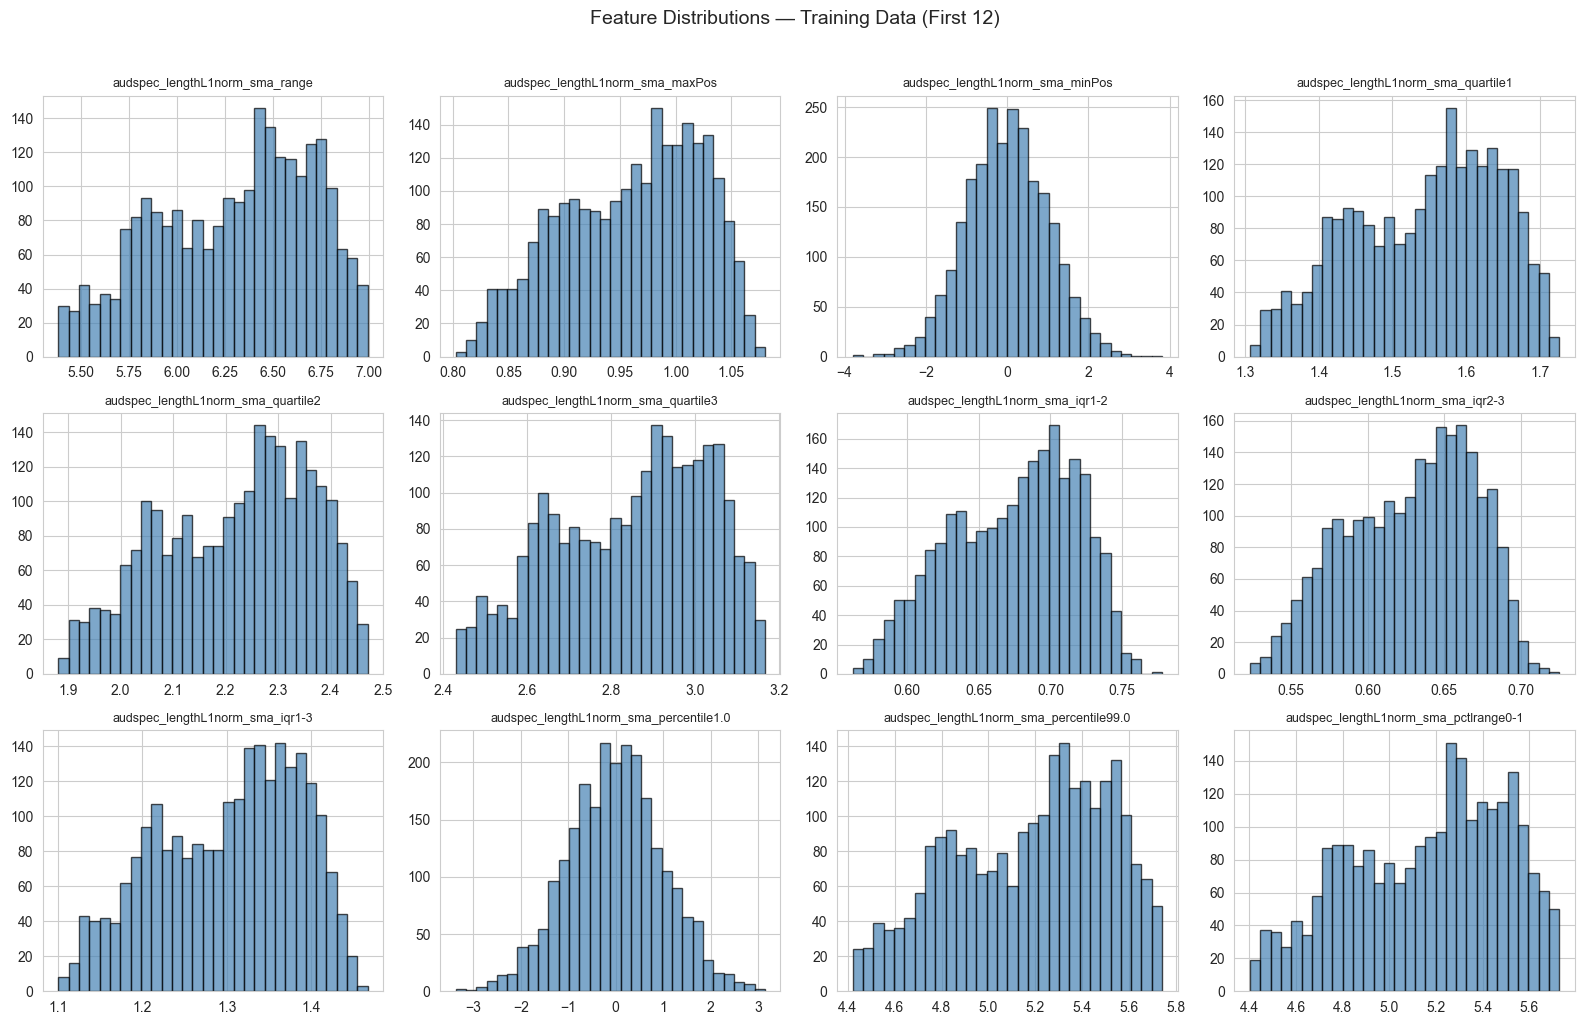


--- 10.2 Correlation Analysis ---
  Found 9691871 highly correlated pairs (|r| >= 0.85):
    audspecRasta_lengthL1norm_sma_range <-> audspecRasta_lengthL1norm_sma_kurtosis: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> audspecRasta_lengthL1norm_sma_maxSegLen: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> pcm_zcr_sma_kurtosis: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> audspec_lengthL1norm_sma_de_kurtosis: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> audspecRasta_lengthL1norm_sma_de_range: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> audspecRasta_lengthL1norm_sma_de_kurtosis: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> pcm_RMSenergy_sma_de_kurtosis: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> pcm_zcr_sma_de_kurtosis: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> audSpec_Rfilt_sma[0]_kurtosis: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> audSpec_Rfilt_sma[1]_range: r = 1.0
    audspecRasta_lengthL1norm_sma_range <-> audSpec

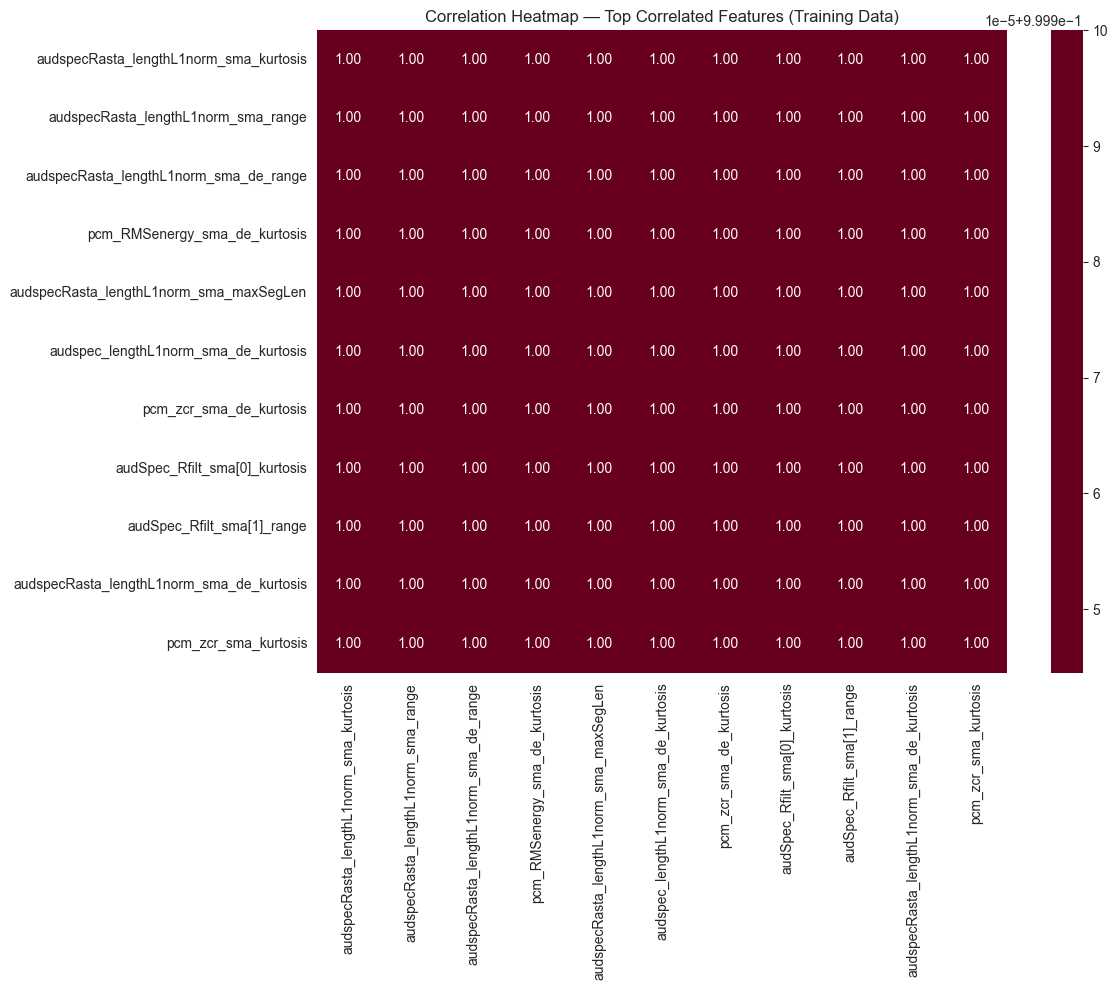


--- 10.3 Statistical Tests (Feature vs Target — Training Data) ---
  Running Kruskal-Wallis H-test (non-parametric) for each feature vs target...
  Results: 5534/6373 features are statistically significant (p < 0.05)

  Top 10 features by H-statistic:
    pcm_fftMag_fband250-650_sma_de_pctlrange0-1 H=   1795.98  p=0.00e+00  [SIG]
    pcm_fftMag_spectralRollOff25.0_sma_de_segLenStddev H=   1795.67  p=0.00e+00  [SIG]
    mfcc_sma[1]_maxSegLen               H=   1795.48  p=0.00e+00  [SIG]
    audSpec_Rfilt_sma[19]_meanSegLen    H=   1795.48  p=0.00e+00  [SIG]
    mfcc_sma[7]_iqr1-2                  H=   1795.44  p=0.00e+00  [SIG]
    audSpec_Rfilt_sma_de[5]_peakMeanMeanDist H=   1795.31  p=0.00e+00  [SIG]
    audspec_lengthL1norm_sma_de_stddevFallingSlope H=   1795.26  p=0.00e+00  [SIG]
    pcm_fftMag_spectralSkewness_sma_quartile2 H=   1795.24  p=0.00e+00  [SIG]
    audspec_lengthL1norm_sma_range      H=   1795.14  p=0.00e+00  [SIG]
    pcm_fftMag_spectralRollOff75.0_sma_skewness H=   1

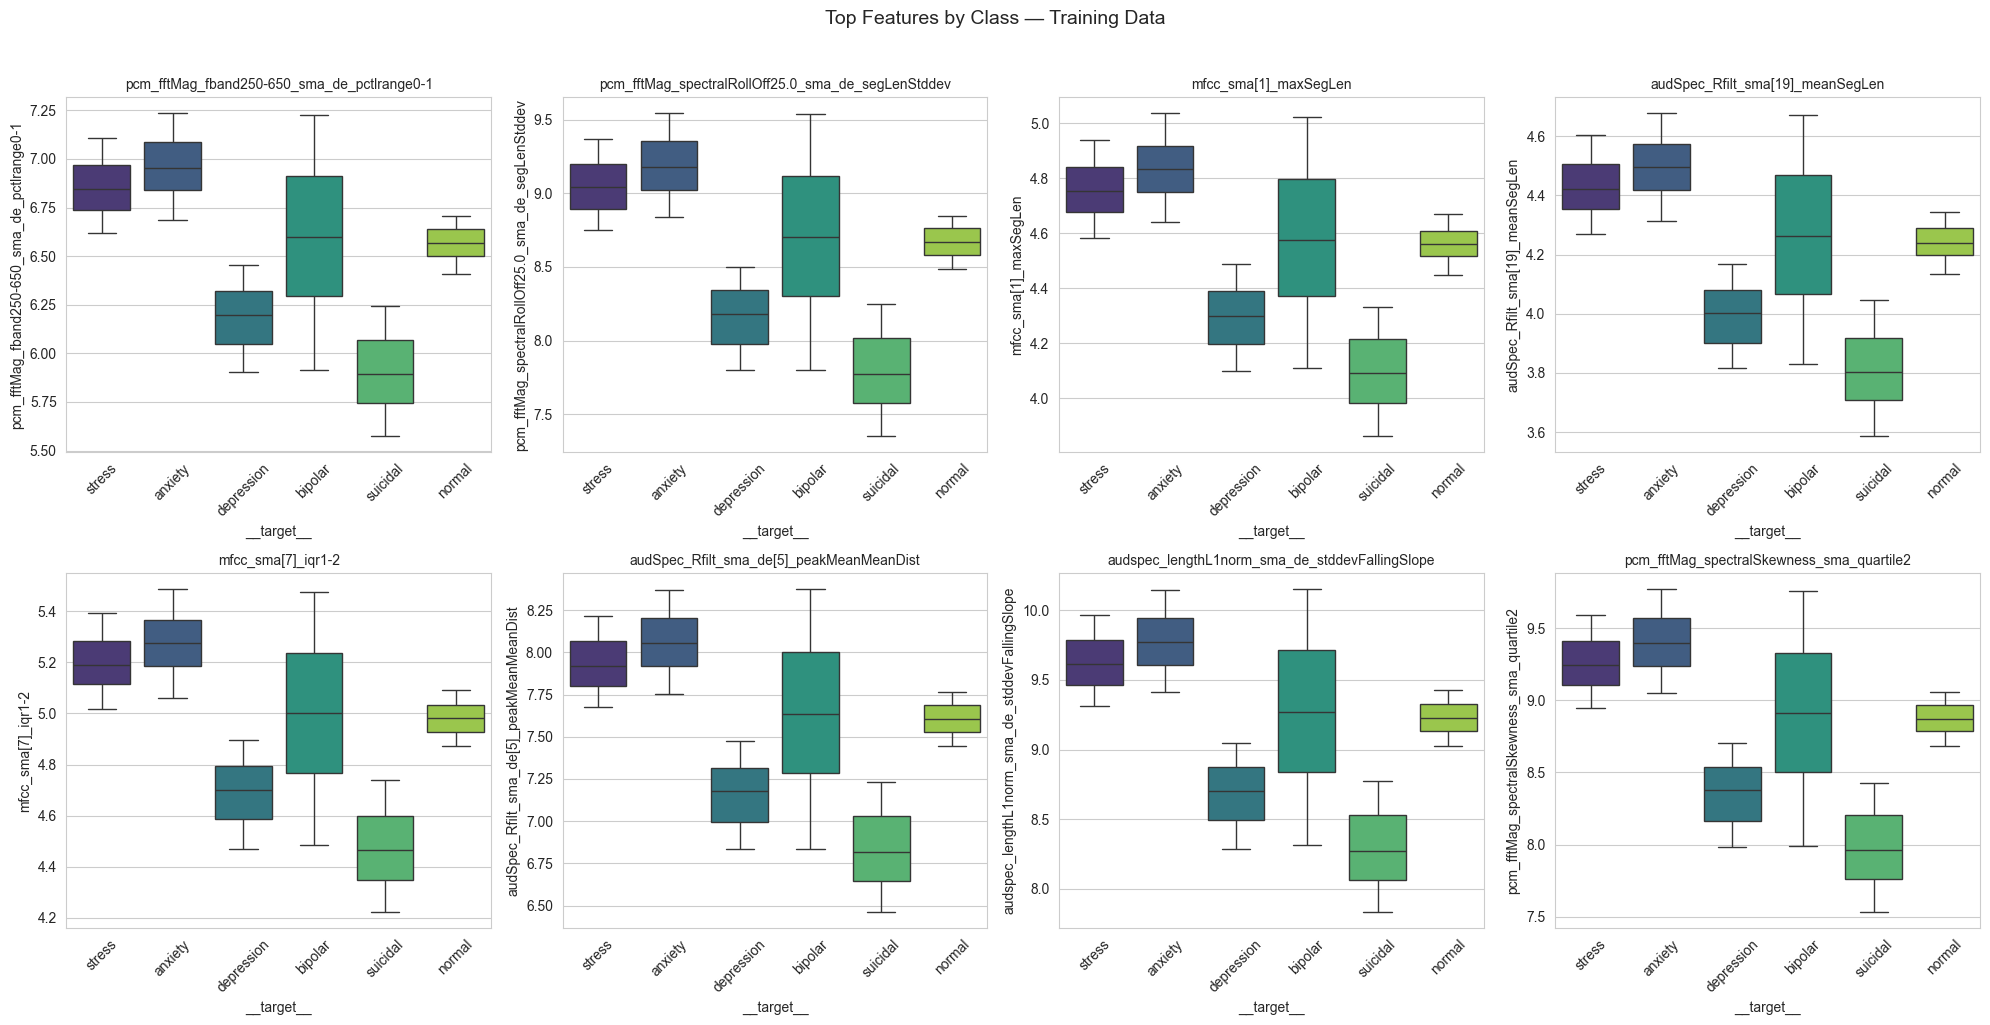


Step 10 complete.


In [21]:
print('=' * 70)
print('STEP 10: EXPLORATORY DATA ANALYSIS & VISUALIZATION (TRAIN ONLY)')
print('=' * 70)

numeric_cols_eda = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
n_feat = len(numeric_cols_eda)
print(f'\nAnalyzing {n_feat} numeric features (training data only)...\n')

# ─── 10.1 Distribution Analysis ─────────────────────────────────────
print('--- 10.1 Feature Distribution Analysis ---')
skewness_report = {}
for col in numeric_cols_eda:
    vals = X_train_df[col].dropna()
    sk = float(stats.skew(vals)) if len(vals) > 2 else 0.0
    kt = float(stats.kurtosis(vals)) if len(vals) > 2 else 0.0
    skewness_report[col] = {'skewness': round(sk, 4), 'kurtosis': round(kt, 4)}

sorted_skew = sorted(skewness_report.items(), key=lambda x: abs(x[1]['skewness']),
                      reverse=True)
print(f'  Top 10 most skewed features:')
for col, vals in sorted_skew[:10]:
    label = 'HIGH' if abs(vals['skewness']) > 2 else 'MOD' if abs(vals['skewness']) > 1 else 'LOW'
    print(f'    {col:<35} skew={vals["skewness"]:>7.3f}  kurtosis={vals["kurtosis"]:>7.3f}  [{label}]')

# Plot distributions (first 12 features)
n_plot = min(12, n_feat)
if n_plot > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.flatten()
    for i in range(n_plot):
        col = numeric_cols_eda[i]
        axes[i].hist(X_train_df[col].dropna(), bins=30, edgecolor='black', alpha=0.7,
                     color='steelblue')
        axes[i].set_title(col, fontsize=9)
    for i in range(n_plot, len(axes)):
        axes[i].set_visible(False)
    plt.suptitle('Feature Distributions — Training Data (First 12)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# ─── 10.2 Correlation Analysis ──────────────────────────────────────
print('\n--- 10.2 Correlation Analysis ---')
corr_matrix = X_train_df[numeric_cols_eda].corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = abs(corr_matrix.iloc[i, j])
        if r >= 0.85:
            high_corr_pairs.append((corr_matrix.columns[i],
                                    corr_matrix.columns[j],
                                    round(float(r), 4)))

if high_corr_pairs:
    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f'  Found {len(high_corr_pairs)} highly correlated pairs (|r| >= 0.85):')
    for c1, c2, r in high_corr_pairs[:15]:
        print(f'    {c1} <-> {c2}: r = {r}')
    if len(high_corr_pairs) > 15:
        print(f'    ... and {len(high_corr_pairs) - 15} more pairs')
else:
    print('  No highly correlated pairs found (|r| >= 0.85). Features are independent.')

# Heatmap
if n_feat <= 40:
    fig, ax = plt.subplots(figsize=(min(18, n_feat * 0.6), min(14, n_feat * 0.5)))
    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, ax=ax,
                xticklabels=True, yticklabels=True, fmt='.1f')
    ax.set_title('Feature Correlation Heatmap (Training Data)')
    plt.tight_layout()
    plt.show()
else:
    print(f'  Skipping full heatmap ({n_feat} features too many). Showing top correlations only.')
    if high_corr_pairs:
        top_cols = list(set([c1 for c1, _, _ in high_corr_pairs[:10]] +
                            [c2 for _, c2, _ in high_corr_pairs[:10]]))[:20]
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix.loc[top_cols, top_cols], cmap='RdBu_r', center=0,
                    ax=ax, annot=True, fmt='.2f')
        ax.set_title('Correlation Heatmap — Top Correlated Features (Training Data)')
        plt.tight_layout()
        plt.show()

# ─── 10.3 Statistical Tests (on training data) ──────────────────────
print('\n--- 10.3 Statistical Tests (Feature vs Target — Training Data) ---')
stat_test_results = {}

# We need target labels aligned with training data for grouping
if TASK_TYPE == 'classification':
    # Decode y_train back to class names for grouping
    train_target_labels = le.inverse_transform(y_train) if le else y_train

    print('  Running Kruskal-Wallis H-test (non-parametric) for each feature vs target...')
    classes_unique = np.unique(train_target_labels)

    for col in numeric_cols_eda:
        groups = [X_train_df[col][train_target_labels == c].dropna().values
                  for c in classes_unique]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) >= 2:
            h_stat, p_val = stats.kruskal(*groups)
            stat_test_results[col] = {
                'test': 'kruskal_wallis',
                'H_statistic': round(float(h_stat), 4),
                'p_value': float(p_val),
                'significant': bool(p_val < 0.05)
            }

    sig_count = sum(1 for v in stat_test_results.values() if v['significant'])
    print(f'  Results: {sig_count}/{len(stat_test_results)} features are statistically '
          f'significant (p < 0.05)')

    sorted_tests = sorted(stat_test_results.items(),
                           key=lambda x: x[1]['H_statistic'], reverse=True)
    print(f'\n  Top 10 features by H-statistic:')
    for col, vals in sorted_tests[:10]:
        sig = 'SIG' if vals['significant'] else 'n.s.'
        print(f'    {col:<35} H={vals["H_statistic"]:>10.2f}  '
              f'p={vals["p_value"]:.2e}  [{sig}]')

else:
    print('  Running Spearman correlation for each feature vs target...')
    for col in numeric_cols_eda:
        vals = X_train_df[col].dropna()
        target_aligned = y_train[:len(vals)]
        if len(vals) >= 3:
            rho, p_val = stats.spearmanr(vals, target_aligned)
            stat_test_results[col] = {
                'test': 'spearman_correlation',
                'rho': round(float(rho), 4),
                'p_value': float(p_val),
                'significant': bool(p_val < 0.05)
            }

    sig_count = sum(1 for v in stat_test_results.values() if v['significant'])
    sorted_tests = sorted(stat_test_results.items(),
                           key=lambda x: abs(x[1]['rho']), reverse=True)
    print(f'  Results: {sig_count}/{len(stat_test_results)} features significant (p < 0.05)')
    print(f'\n  Top 10 features by |rho|:')
    for col, vals in sorted_tests[:10]:
        sig = 'SIG' if vals['significant'] else 'n.s.'
        print(f'    {col:<35} rho={vals["rho"]:>7.4f}  p={vals["p_value"]:.2e}  [{sig}]')

# ─── 10.4 Levene's Test (Equality of Variances) ─────────────────────
if TASK_TYPE == 'classification':
    print(f'\n--- 10.4 Levene\'s Test (Equality of Variances Across Classes — Train) ---')
    print('  Tests if a feature\'s spread/variance differs across target classes.')
    print('  Unequal variance = feature can distinguish classes by spread, not just mean.')
    levene_results = {}

    for col in numeric_cols_eda:
        groups = [X_train_df[col][train_target_labels == c].dropna().values
                  for c in classes_unique]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) >= 2:
            lev_stat, lev_p = stats.levene(*groups)
            levene_results[col] = {
                'W_statistic': round(float(lev_stat), 4),
                'p_value': float(lev_p),
                'unequal_variance': bool(lev_p < 0.05)
            }

    lev_sig = sum(1 for v in levene_results.values() if v['unequal_variance'])
    print(f'  Results: {lev_sig}/{len(levene_results)} features have significantly '
          f'unequal variance across classes (p < 0.05)')

    sorted_levene = sorted(levene_results.items(),
                            key=lambda x: x[1]['W_statistic'], reverse=True)
    print(f'\n  Top 10 features by Levene W-statistic (most variance difference):')
    for col, vals in sorted_levene[:10]:
        sig = 'UNEQ' if vals['unequal_variance'] else 'EQ'
        print(f'    {col:<35} W={vals["W_statistic"]:>10.2f}  '
              f'p={vals["p_value"]:.2e}  [{sig}]')

    PIPELINE_STATE['levene_test'] = {
        'features_with_unequal_variance': lev_sig,
        'total_tested': len(levene_results),
        'top_10': [(col, vals['W_statistic']) for col, vals in sorted_levene[:10]]
    }
else:
    print(f'\n--- 10.4 Levene\'s Test ---')
    print('  Skipped (Levene\'s test is for classification tasks only).')

# ─── 10.5 Box Plots by Class (classification) ───────────────────────
if TASK_TYPE == 'classification' and len(sorted_tests) > 0:
    print(f'\n--- 10.5 Box Plots by Class — Training Data (Top 8 Features) ---')
    top_feat_names = [col for col, _ in sorted_tests[:8]]
    n_bp = min(8, len(top_feat_names))

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    plot_df = X_train_df.copy()
    plot_df['__target__'] = train_target_labels
    for i in range(n_bp):
        col = top_feat_names[i]
        sns.boxplot(data=plot_df, x='__target__', y=col, ax=axes[i],
                    palette='viridis')
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
    for i in range(n_bp, len(axes)):
        axes[i].set_visible(False)
    plt.suptitle('Top Features by Class — Training Data', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

PIPELINE_STATE['eda'] = {
    'n_features_analyzed': n_feat,
    'significant_features': sig_count,
    'high_corr_pairs_count': len(high_corr_pairs),
    'skewness': skewness_report,
    'levene_features_unequal_var': lev_sig if TASK_TYPE == 'classification' else 'N/A'
}

print(f'\nStep 10 complete.')

## Step 11 — Feature Selection (Multi-Method Consensus — Train Only)
Progressive feature elimination using **training data only**:
1. **Correlation filtering** — remove one from each highly-correlated pair (|r| >= 0.85)
2. **VIF** — iteratively remove features with VIF > 10 (**protected**: top-25% importance features are never removed)
3. **Random Forest** feature importance (MDI) — fit on training data
4. **Mutual Information** scores — computed on training data
5. **Statistical tests** (Kruskal-Wallis H / Spearman rho + Levene's W for classification)

Methods 3-5 produce a consensus ranking; features below the **MI > 0.01** absolute threshold
(or bottom 30%, whichever drops fewer) are pruned.

In [ ]:
print('=' * 70)
print('STEP 11: FEATURE SELECTION (MULTI-METHOD CONSENSUS — TRAIN ONLY)')
print('=' * 70)

numeric_cols_fs = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
n_features_start = len(numeric_cols_fs)
print(f'\nStarting with {n_features_start} features.')

# ─── 11.1 Remove Highly Correlated Features ─────────────────────────
print(f'\n--- 11.1 Correlation-Based Filtering ---')
cols_to_remove_corr = set()

if high_corr_pairs:
    for c1, c2, r in high_corr_pairs:
        if c1 not in numeric_cols_fs or c2 not in numeric_cols_fs:
            continue
        # Keep the feature more related to target
        if TASK_TYPE == 'classification':
            score1 = stat_test_results.get(c1, {}).get('H_statistic', 0)
            score2 = stat_test_results.get(c2, {}).get('H_statistic', 0)
        else:
            score1 = abs(stat_test_results.get(c1, {}).get('rho', 0))
            score2 = abs(stat_test_results.get(c2, {}).get('rho', 0))
        remove = c2 if score1 >= score2 else c1
        if remove in numeric_cols_fs:
            cols_to_remove_corr.add(remove)

    if cols_to_remove_corr:
        print(f'  Removing {len(cols_to_remove_corr)} redundant features:')
        for col in sorted(cols_to_remove_corr):
            print(f'    [-] {col}')
        X_train_df = X_train_df.drop(columns=list(cols_to_remove_corr), errors='ignore')
        X_test_df = X_test_df.drop(columns=list(cols_to_remove_corr), errors='ignore')
    else:
        print('  No features removed after correlation analysis.')
else:
    print('  No highly correlated pairs to filter.')

numeric_cols_fs = X_train_df.select_dtypes(include=[np.number]).columns.tolist()

# ─── 11.2 Feature Importance (GPU-accelerated when available) ────────
print(f'\n--- 11.2 Feature Importance (Train Only) ---')
sample_size = min(len(X_train_df), 30000)
idx = np.random.choice(len(X_train_df), sample_size, replace=False)
X_sample = X_train_df.iloc[idx][numeric_cols_fs].values
y_sample = y_train[idx]

# Use XGBoost on GPU if available (much faster), else fall back to RandomForest (CPU, all cores)
if GPU_AVAILABLE:
    print(f'  Using XGBoost [GPU] for feature importance ({sample_size:,} samples)...')
    if TASK_TYPE == 'classification':
        imp_model = xgb.XGBClassifier(
            n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1,
            device='cuda', tree_method='hist', eval_metric='mlogloss',
            verbosity=0)
    else:
        imp_model = xgb.XGBRegressor(
            n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1,
            device='cuda', tree_method='hist', verbosity=0)
else:
    print(f'  Using RandomForest [CPU, {CPU_COUNT} cores] for feature importance ({sample_size:,} samples)...')
    if TASK_TYPE == 'classification':
        imp_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    else:
        imp_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

imp_model.fit(X_sample, y_sample)
rf_importance = dict(zip(numeric_cols_fs, imp_model.feature_importances_))
rf_sorted = sorted(rf_importance.items(), key=lambda x: x[1], reverse=True)

imp_method = 'XGBoost [GPU]' if GPU_AVAILABLE else 'RandomForest [CPU]'
print(f'  Top 15 by {imp_method} Importance:')
for col, imp in rf_sorted[:15]:
    bar = '#' * int(imp * 200)
    print(f'    {col:<35} {imp:.4f} |{bar}')

# Identify top-25% features (protected from VIF removal)
top_25_count = max(1, len(rf_sorted) // 4)
protected_features = set(col for col, _ in rf_sorted[:top_25_count])
print(f'\n  Top-25% features ({top_25_count}) are PROTECTED from VIF removal.')

# ─── 11.3 VIF — Variance Inflation Factor (with protection) ─────────
print(f'\n--- 11.3 VIF (Multicollinearity Detection — Top Features Protected) ---')
print('  VIF > 10 means a feature is highly predictable from other features.')
print('  Top-25% importance features will NOT be removed even if VIF > 10.')
print('  Iteratively removing the worst unprotected offender until all VIF <= 10...\n')

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_removed = []
max_vif_iters = 20  # safety limit

for vif_round in range(max_vif_iters):
    vif_cols = X_train_df[numeric_cols_fs].columns.tolist()
    if len(vif_cols) <= 2:
        break
    # Use a sample for speed on large datasets
    vif_sample = X_train_df[vif_cols].dropna()
    if len(vif_sample) > 10000:
        vif_sample = vif_sample.sample(10000, random_state=RANDOM_SEED)
    vif_data = vif_sample.values.astype(float)

    # Replace any inf/nan to avoid errors
    vif_data = np.nan_to_num(vif_data, nan=0.0, posinf=0.0, neginf=0.0)

    vif_scores = {}
    for i, col in enumerate(vif_cols):
        try:
            vif_scores[col] = variance_inflation_factor(vif_data, i)
        except Exception:
            vif_scores[col] = 0.0

    # Find worst VIF among UNPROTECTED features only
    unprotected_vif = {c: v for c, v in vif_scores.items() if c not in protected_features}
    if not unprotected_vif:
        # All remaining high-VIF features are protected
        still_high = {c: v for c, v in vif_scores.items() if v > 10}
        if still_high:
            print(f'  Remaining high-VIF features are all protected (top-25% importance):')
            for c, v in sorted(still_high.items(), key=lambda x: x[1], reverse=True):
                print(f'    [KEPT] {c} (VIF = {v:.1f}) — protected by importance rank')
        break

    worst_col = max(unprotected_vif, key=unprotected_vif.get)
    worst_vif = unprotected_vif[worst_col]

    if worst_vif <= 10:
        print(f'  All unprotected VIF values <= 10 after {vif_round} round(s). Done.')
        break

    print(f'  Round {vif_round + 1}: Removing {worst_col} (VIF = {worst_vif:.1f})')
    vif_removed.append((worst_col, round(worst_vif, 1)))
    X_train_df = X_train_df.drop(columns=[worst_col], errors='ignore')
    X_test_df = X_test_df.drop(columns=[worst_col], errors='ignore')
    numeric_cols_fs = [c for c in numeric_cols_fs if c != worst_col]
else:
    print(f'  Stopped after {max_vif_iters} rounds (safety limit).')

if vif_removed:
    print(f'\n  VIF Summary: Removed {len(vif_removed)} multicollinear feature(s):')
    for col, vif_val in vif_removed:
        print(f'    [-] {col} (VIF = {vif_val})')
else:
    print(f'  No features removed — all VIF values are acceptable (or protected).')

print(f'  Features remaining: {len(numeric_cols_fs)}')

PIPELINE_STATE['vif_removal'] = {
    'features_removed': vif_removed,
    'features_remaining': len(numeric_cols_fs),
    'protected_features': list(protected_features)
}

# ─── 11.4 Mutual Information ────────────────────────────────────────
print(f'\n--- 11.4 Mutual Information Scores (Train Only) ---')
mi_func = mutual_info_classif if TASK_TYPE == 'classification' else mutual_info_regression
mi_scores = mi_func(X_train_df[numeric_cols_fs].fillna(0).values, y_train,
                     random_state=RANDOM_SEED)
mi_importance = dict(zip(numeric_cols_fs, mi_scores))
mi_sorted = sorted(mi_importance.items(), key=lambda x: x[1], reverse=True)

print(f'  Top 15 by Mutual Information:')
for col, mi in mi_sorted[:15]:
    bar = '#' * int(mi * 50)
    print(f'    {col:<35} {mi:.4f} |{bar}')

# ─── 11.5 Consensus Ranking ─────────────────────────────────────────
print(f'\n--- 11.5 Consensus Feature Ranking ---')
rf_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(rf_sorted)
            if feat in numeric_cols_fs}
mi_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(mi_sorted)}

# Statistical test ranking
if TASK_TYPE == 'classification':
    stat_filtered = [(col, stat_test_results[col]['H_statistic'])
                     for col in numeric_cols_fs if col in stat_test_results]
    stat_sorted_fs = sorted(stat_filtered, key=lambda x: x[1], reverse=True)
else:
    stat_filtered = [(col, abs(stat_test_results[col]['rho']))
                     for col in numeric_cols_fs if col in stat_test_results]
    stat_sorted_fs = sorted(stat_filtered, key=lambda x: x[1], reverse=True)

stat_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(stat_sorted_fs)}

# Levene's ranking (classification only)
levene_ranks = {}
if TASK_TYPE == 'classification' and levene_results:
    lev_filtered = [(col, levene_results[col]['W_statistic'])
                    for col in numeric_cols_fs if col in levene_results]
    lev_sorted_fs = sorted(lev_filtered, key=lambda x: x[1], reverse=True)
    levene_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(lev_sorted_fs)}
    print(f'  Using 4-method consensus: Importance + MI + Kruskal-Wallis + Levene\'s')
else:
    print(f'  Using 3-method consensus: Importance + MI + Statistical test')

consensus = {}
for feat in numeric_cols_fs:
    ranks = [
        rf_ranks.get(feat, len(numeric_cols_fs)),
        mi_ranks.get(feat, len(numeric_cols_fs)),
        stat_ranks.get(feat, len(numeric_cols_fs))
    ]
    if levene_ranks:
        ranks.append(levene_ranks.get(feat, len(numeric_cols_fs)))
    consensus[feat] = np.mean(ranks)

consensus_sorted = sorted(consensus.items(), key=lambda x: x[1])
n_total = len(consensus_sorted)

print(f'  Consensus Ranking (average of Importance + MI + Stat ranks):')
for rank, (feat, avg_rank) in enumerate(consensus_sorted[:20], 1):
    pct = rank / n_total * 100
    tier = 'T1' if pct <= 15 else 'T2' if pct <= 40 else 'T3' if pct <= 70 else 'T4'
    print(f'    {rank:>3}. [{tier}] {feat:<35} avg_rank: {avg_rank:.1f}')
if n_total > 20:
    print(f'    ... ({n_total - 20} more features)')

# ─── 11.6 Feature Pruning (smarter: absolute MI threshold + percentage floor) ───
print(f'\n--- 11.6 Feature Pruning ---')

# Method 1: drop features with MI below threshold (noise)
mi_threshold = 0.01
mi_drop = set(feat for feat, mi_val in mi_importance.items() if mi_val < mi_threshold)

# Method 2: drop bottom 30% by consensus
pct_keep = int(n_total * 0.7)
pct_drop = set(feat for feat, _ in consensus_sorted[pct_keep:])

# Use the LESS aggressive of the two (drop fewer features)
if len(mi_drop) < len(pct_drop):
    features_to_drop = sorted(mi_drop, key=lambda f: consensus.get(f, 0), reverse=True)
    prune_method = f'MI < {mi_threshold} threshold (less aggressive than 30% cutoff)'
else:
    features_to_drop = [feat for feat, _ in consensus_sorted[pct_keep:]]
    prune_method = f'bottom {n_total - pct_keep} by consensus rank (less aggressive than MI threshold)'

features_to_keep = [f for f in [feat for feat, _ in consensus_sorted] if f not in features_to_drop]

if features_to_drop:
    print(f'  Pruning method: {prune_method}')
    print(f'  Keeping {len(features_to_keep)}/{n_total} features')
    print(f'  Dropping {len(features_to_drop)} low-importance features:')
    for feat in features_to_drop:
        mi_val = mi_importance.get(feat, 0)
        print(f'    [-] {feat} (avg rank: {consensus[feat]:.1f}, MI: {mi_val:.4f})')
    X_train_df = X_train_df[features_to_keep]
    X_test_df = X_test_df[features_to_keep]
else:
    print(f'  All {n_total} features retained (all above MI threshold and consensus cutoff).')

# ─── Importance Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, min(12, n_features_start * 0.3))))
top_rf = [(f, s) for f, s in rf_sorted if f in features_to_keep][:15]
axes[0].barh([x[0] for x in top_rf][::-1], [x[1] for x in top_rf][::-1],
             color='steelblue', edgecolor='black')
axes[0].set_title(f'{imp_method} Importance (Top 15 Kept)')
axes[0].set_xlabel('Importance')

top_mi = [(f, s) for f, s in mi_sorted if f in features_to_keep][:15]
axes[1].barh([x[0] for x in top_mi][::-1], [x[1] for x in top_mi][::-1],
             color='coral', edgecolor='black')
axes[1].set_title('Mutual Information (Top 15 Kept)')
axes[1].set_xlabel('MI Score')
plt.tight_layout()
plt.show()

print(f'\n  Final feature count: {X_train_df.shape[1]}')

PIPELINE_STATE['feature_selection'] = {
    'initial_features': n_features_start,
    'removed_correlation': list(cols_to_remove_corr),
    'consensus_top_20': [(f, round(float(r), 2)) for f, r in consensus_sorted[:20]],
    'features_kept': features_to_keep,
    'features_dropped': features_to_drop,
    'prune_method': prune_method,
    'final_count': int(X_train_df.shape[1]),
    'importance_method': imp_method
}

print(f'\nStep 11 complete.')

STEP 11: FEATURE SELECTION (MULTI-METHOD CONSENSUS — TRAIN ONLY)

Starting with 6373 features.

--- 11.1 Correlation-Based Filtering ---
  Removing 4443 redundant features:
    [-]  
    [-] F0final_sma_amean
    [-] F0final_sma_centroid
    [-] F0final_sma_de_kurtosis
    [-] F0final_sma_de_leftctime
    [-] F0final_sma_de_linregc2
    [-] F0final_sma_de_lpc0
    [-] F0final_sma_de_lpc1
    [-] F0final_sma_de_maxPos
    [-] F0final_sma_de_qregc3
    [-] F0final_sma_de_range
    [-] F0final_sma_de_risetime
    [-] F0final_sma_de_skewness
    [-] F0final_sma_de_upleveltime25
    [-] F0final_sma_de_upleveltime50
    [-] F0final_sma_de_upleveltime75
    [-] F0final_sma_de_upleveltime90
    [-] F0final_sma_ff0_maxSegLen
    [-] F0final_sma_ff0_meanSegLen
    [-] F0final_sma_ff0_nnz
    [-] F0final_sma_ff0_segLenStddev
    [-] F0final_sma_flatness
    [-] F0final_sma_iqr1-2
    [-] F0final_sma_iqr1-3
    [-] F0final_sma_iqr2-3
    [-] F0final_sma_kurtosis
    [-] F0final_sma_leftctime
    [

## Step 12 — Feature Scaling
Scale features using a scaler chosen based on data characteristics.
The scaler is **fit on training data only** and applied to both train and test sets.

In [ ]:
print('=' * 70)
print('STEP 12: FEATURE SCALING')
print('=' * 70)

# Feature names from post-selection DataFrames
feature_names = X_train_df.columns.tolist()
print(f'\nFeatures entering scaling: {len(feature_names)}')
print(f'  Train samples: {X_train_df.shape[0]:,}')
print(f'  Test  samples: {X_test_df.shape[0]:,}')

# Convert to numpy
X_train = X_train_df.values.astype(np.float64)
X_test = X_test_df.values.astype(np.float64)

# Handle any remaining NaN/Inf
for label, arr in [('Train', X_train), ('Test', X_test)]:
    nan_c = np.isnan(arr).sum()
    inf_c = np.isinf(arr).sum()
    if nan_c > 0 or inf_c > 0:
        print(f'\n  Cleaning {label}: {nan_c} NaN, {inf_c} Inf values → replaced with 0')
        arr[:] = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

# ─── Scaler Selection ───────────────────────────────────────────────
print(f'\n--- Scaler Selection ---')
n_outlier_cols = len(PIPELINE_STATE.get('outlier_handling', {}).get('transformations', {}))
total_features = len(feature_names)

if n_outlier_cols > total_features * 0.3:
    scaler = RobustScaler()
    scaler_name = 'RobustScaler'
    print(f'  Many columns required outlier smoothing ({n_outlier_cols}/{total_features}).')
    print(f'  Using RobustScaler (median/IQR based) for extra robustness.')
else:
    scaler = StandardScaler()
    scaler_name = 'StandardScaler'
    print(f'  Outlier situation is manageable ({n_outlier_cols}/{total_features} columns treated).')
    print(f'  Using StandardScaler (zero mean, unit variance).')

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\n  Scaling applied with {scaler_name}')
print(f'  Train — mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}')
print(f'  Test  — mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}')

PIPELINE_STATE['preprocessing'] = {
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'train_size': int(X_train_scaled.shape[0]),
    'test_size': int(X_test_scaled.shape[0]),
    'scaler': scaler_name,
    'class_names': class_names
}
print(f'\nStep 12 complete.')

STEP 12: FEATURE SCALING

Features entering scaling: 43
  Train samples: 40,000
  Test  samples: 10,000

--- Scaler Selection ---
  Many columns required outlier smoothing (63/43).
  Using RobustScaler (median/IQR based) for extra robustness.

  Scaling applied with RobustScaler
  Train — mean: 0.015448, std: 0.704962
  Test  — mean: 0.015821, std: 0.705569

Step 12 complete.


## Step 13 — Model Shortlisting
Dynamically select candidate models based on dataset properties (size, dimensionality, task type).

In [ ]:
print('=' * 70)
print('STEP 13: MODEL SHORTLISTING')
print('=' * 70)

n_samples = X_train_scaled.shape[0]
n_feats = X_train_scaled.shape[1]

print(f'\nData characteristics:')
print(f'  Training samples : {n_samples:,}')
print(f'  Features         : {n_feats}')
print(f'  Task             : {TASK_TYPE}')
print(f'  CPU cores        : {CPU_COUNT}')
print(f'  GPU acceleration : {"YES (" + GPU_NAME + ")" if GPU_AVAILABLE else "NO (CPU only)"}')
if TASK_TYPE == 'classification':
    print(f'  Classes          : {len(class_names) if class_names else "N/A"}')
    print(f'  Balance strategy : {BALANCE_STRATEGY}')

candidates = OrderedDict()
selection_reasons = {}
use_cw = BALANCE_STRATEGY in ['class_weight', 'class_weight_heavy']

# ─── Compute sample_weight for models that don't support class_weight ────
sample_weight_train = None
if TASK_TYPE == 'classification' and use_cw:
    from sklearn.utils.class_weight import compute_sample_weight
    sample_weight_train = compute_sample_weight('balanced', y_train)
    print(f'\n  Computed sample_weight (balanced) for XGBoost.')
    print(f'  Weight range: [{sample_weight_train.min():.3f}, {sample_weight_train.max():.3f}]')

if TASK_TYPE == 'classification':
    # --- Always include ---
    candidates['Random Forest'] = RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1,
        class_weight='balanced' if use_cw else None)
    selection_reasons['Random Forest'] = 'Always included — robust, handles mixed features'

    lgb_params = {'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1}
    if use_cw:
        lgb_params['is_unbalance'] = True
    if GPU_AVAILABLE:
        lgb_params['device'] = 'gpu'
    candidates['LightGBM'] = lgb.LGBMClassifier(**lgb_params)
    gpu_tag = ' [GPU]' if GPU_AVAILABLE else ''
    selection_reasons['LightGBM'] = f'Always included — fast, state-of-the-art{gpu_tag}'

    candidates['Extra Trees'] = ExtraTreesClassifier(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1,
        class_weight='balanced' if use_cw else None)
    selection_reasons['Extra Trees'] = 'Always included — more randomized variant of RF'

    # --- Conditional ---
    if n_samples <= 100000:
        xgb_params = {'random_state': RANDOM_SEED, 'n_jobs': -1, 'eval_metric': 'mlogloss'}
        if GPU_AVAILABLE:
            xgb_params['device'] = 'cuda'
            xgb_params['tree_method'] = 'hist'
        candidates['XGBoost'] = xgb.XGBClassifier(**xgb_params)
        reason = f'Included — dataset size ({n_samples:,}) manageable'
        if use_cw:
            reason += ' (sample_weight)'
        if GPU_AVAILABLE:
            reason += ' [GPU]'
        selection_reasons['XGBoost'] = reason
    else:
        selection_reasons['XGBoost [SKIPPED]'] = f'Skipped — too large ({n_samples:,}), prefer LightGBM'
        print(f'  Skipping XGBoost: dataset too large ({n_samples:,}). LightGBM preferred.')

    # HistGradientBoosting replaces GradientBoosting — 10-100x faster, uses all CPU cores
    candidates['HistGradientBoosting'] = HistGradientBoostingClassifier(
        max_iter=200, random_state=RANDOM_SEED,
        class_weight='balanced' if use_cw else None)
    selection_reasons['HistGradientBoosting'] = (
        f'Included — histogram-based GB, native parallel ({CPU_COUNT} cores), '
        f'replaces slow GradientBoosting')

    if n_feats < 100 and n_samples <= 50000:
        candidates['Logistic Regression'] = LogisticRegression(
            random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1,
            class_weight='balanced' if use_cw else None)
        selection_reasons['Logistic Regression'] = (
            f'Included — {n_feats} features, {n_samples:,} samples, linear baseline feasible')

    if n_feats < 50 and n_samples <= 20000:
        candidates['SVM (RBF)'] = SVC(
            random_state=RANDOM_SEED, probability=True,
            class_weight='balanced' if use_cw else None)
        selection_reasons['SVM (RBF)'] = (
            f'Included — {n_feats} features, {n_samples:,} samples, SVM feasible')

    if n_samples <= 50000:
        candidates['KNN'] = KNeighborsClassifier(n_jobs=-1)
        selection_reasons['KNN'] = f'Included — dataset size ({n_samples:,}) manageable for KNN'

else:  # regression
    candidates['Random Forest'] = RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    selection_reasons['Random Forest'] = 'Always included — robust baseline'

    lgb_params_r = {'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1}
    if GPU_AVAILABLE:
        lgb_params_r['device'] = 'gpu'
    candidates['LightGBM'] = lgb.LGBMRegressor(**lgb_params_r)
    gpu_tag = ' [GPU]' if GPU_AVAILABLE else ''
    selection_reasons['LightGBM'] = f'Always included — fast, state-of-the-art{gpu_tag}'

    candidates['Extra Trees'] = ExtraTreesRegressor(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    selection_reasons['Extra Trees'] = 'Always included — randomized variant'

    if n_samples <= 100000:
        xgb_params_r = {'random_state': RANDOM_SEED, 'n_jobs': -1}
        if GPU_AVAILABLE:
            xgb_params_r['device'] = 'cuda'
            xgb_params_r['tree_method'] = 'hist'
        candidates['XGBoost'] = xgb.XGBRegressor(**xgb_params_r)
        reason = f'Included — manageable size ({n_samples:,})'
        if GPU_AVAILABLE:
            reason += ' [GPU]'
        selection_reasons['XGBoost'] = reason

    candidates['HistGradientBoosting'] = HistGradientBoostingRegressor(
        max_iter=200, random_state=RANDOM_SEED)
    selection_reasons['HistGradientBoosting'] = (
        f'Included — histogram-based GB, native parallel ({CPU_COUNT} cores)')

    if n_feats < 100:
        candidates['Ridge'] = Ridge(alpha=1.0)
        selection_reasons['Ridge'] = f'Included — {n_feats} features, linear baseline'

    if n_feats < 50 and n_samples <= 20000:
        candidates['SVR'] = SVR()
        selection_reasons['SVR'] = f'Included — small enough for SVR'

    if n_samples <= 50000:
        candidates['KNN'] = KNeighborsRegressor(n_jobs=-1)
        selection_reasons['KNN'] = f'Included — manageable size ({n_samples:,})'

# ─── Models needing sample_weight (for Step 14) ─────────────────────
# Only XGBoost needs sample_weight — HistGB supports class_weight natively
MODELS_NEEDING_SAMPLE_WEIGHT = set()
if TASK_TYPE == 'classification' and use_cw:
    for name in candidates:
        if 'XGBoost' in name:
            MODELS_NEEDING_SAMPLE_WEIGHT.add(name)

print(f'\nSelected {len(candidates)} candidate models:\n')
for name in candidates:
    reason = selection_reasons.get(name, '')
    sw_tag = ' [sample_weight]' if name in MODELS_NEEDING_SAMPLE_WEIGHT else ''
    print(f'  [+] {name}{sw_tag}')
    print(f'      {reason}\n')

for name, reason in selection_reasons.items():
    if 'SKIPPED' in name:
        print(f'  [-] {name}')
        print(f'      {reason}\n')

PIPELINE_STATE['model_shortlist'] = {
    'n_candidates': len(candidates),
    'models': list(candidates.keys()),
    'reasons': selection_reasons,
    'models_with_sample_weight': list(MODELS_NEEDING_SAMPLE_WEIGHT),
    'gpu_used': GPU_AVAILABLE,
    'cpu_cores': CPU_COUNT
}
print(f'\nStep 13 complete.')

STEP 13: MODEL SHORTLISTING

Data characteristics:
  Training samples : 40,000
  Features         : 43
  Task             : classification
  CPU cores        : 8
  GPU acceleration : YES (NVIDIA GeForce GTX 1650 Ti)
  Classes          : 7
  Balance strategy : class_weight

  Computed sample_weight (balanced) for XGBoost.
  Weight range: [0.633, 1.609]

Selected 7 candidate models:

  [+] Random Forest
      Always included — robust, handles mixed features

  [+] LightGBM
      Always included — fast, state-of-the-art [GPU]

  [+] Extra Trees
      Always included — more randomized variant of RF

  [+] XGBoost [sample_weight]
      Included — dataset size (40,000) manageable (sample_weight) [GPU]

  [+] HistGradientBoosting
      Included — histogram-based GB, native parallel (8 cores), replaces slow GradientBoosting

  [+] Logistic Regression
      Included — 43 features, 40,000 samples, linear baseline feasible

  [+] KNN
      Included — dataset size (40,000) manageable for KNN


Ste

## Step 14 — Model Training & Cross-Validation Ranking
Train all candidate models with cross-validation and rank them by **f1_macro** (classification) or neg_MSE (regression).
Models that don't support `class_weight` (XGBoost, Gradient Boosting) use `sample_weight` in `.fit()` via manual CV.

STEP 14: MODEL TRAINING & CROSS-VALIDATION

Cross-Validation Setup:
  Folds   : 5
  Scoring  : f1_macro
  Samples  : 40,000
  Features : 43
  Models using sample_weight in fit(): ['XGBoost']

  Training Random Forest... Done (78.8s) | Score: 0.9082 +/- 0.0032
  Training LightGBM... Done (78.2s) | Score: 0.9194 +/- 0.0028
  Training Extra Trees... Done (26.2s) | Score: 0.8940 +/- 0.0046
  Training XGBoost... Done (21.2s) | Score: 0.9187 +/- 0.0030 [sw]
  Training HistGradientBoosting... Done (23.3s) | Score: 0.9198 +/- 0.0028
  Training Logistic Regression... Done (2.6s) | Score: 0.8820 +/- 0.0037
  Training KNN... Done (3.3s) | Score: 0.7448 +/- 0.0037

MODEL RANKING (by f1_macro)
Rank   Model                     Score          Std        Time
-----------------------------------------------------------------
>>> 1   HistGradientBoosting      0.9198         0.0028     23.3s
>>> 2   LightGBM                  0.9194         0.0028     78.2s
    3   XGBoost                   0.9187        

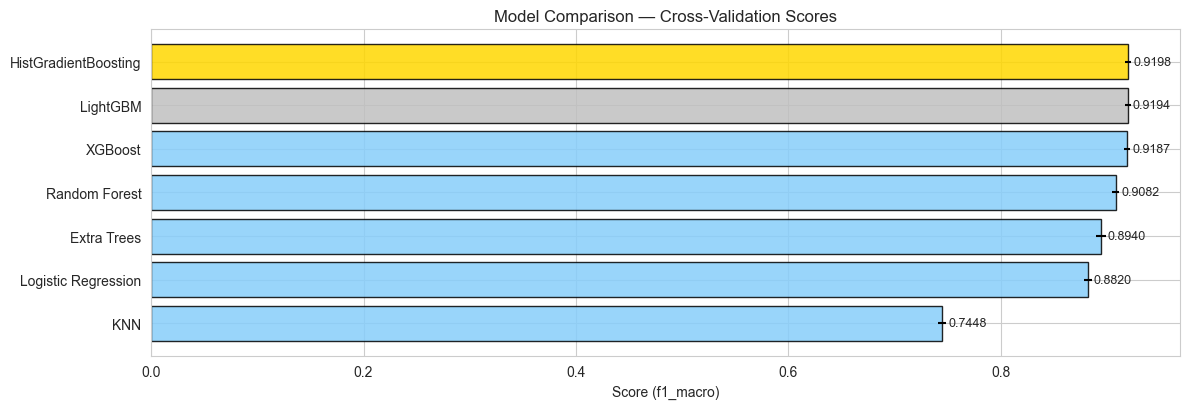


Step 14 complete.


In [ ]:
print('=' * 70)
print('STEP 14: MODEL TRAINING & CROSS-VALIDATION')
print('=' * 70)

n_folds = 5
if TASK_TYPE == 'classification':
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    scoring = 'f1_macro'
else:
    cv = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    scoring = 'neg_mean_squared_error'

print(f'\nCross-Validation Setup:')
print(f'  Folds   : {n_folds}')
print(f'  Scoring  : {scoring}')
print(f'  Samples  : {X_train_scaled.shape[0]:,}')
print(f'  Features : {X_train_scaled.shape[1]}')
if MODELS_NEEDING_SAMPLE_WEIGHT:
    print(f'  Models using sample_weight in fit(): {sorted(MODELS_NEEDING_SAMPLE_WEIGHT)}')
print()


# ─── Helper: train one fold with sample_weight ──────────────────────
def _train_one_fold(model, X_all, y_all, sw_all, train_idx, val_idx):
    """Train a single fold — designed to be called in parallel via joblib."""
    fold_model = copy.deepcopy(model)
    fold_model.fit(X_all[train_idx], y_all[train_idx],
                   sample_weight=sw_all[train_idx])
    y_pred = fold_model.predict(X_all[val_idx])
    return f1_score(y_all[val_idx], y_pred, average='macro', zero_division=0)


model_results = {}

for name, model in candidates.items():
    print(f'  Training {name}...', end=' ', flush=True)
    start_time = time.time()

    try:
        needs_sw = name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None

        if needs_sw:
            # Parallel manual CV so we can pass sample_weight to .fit()
            from joblib import Parallel, delayed
            fold_splits = list(cv.split(X_train_scaled, y_train))
            fold_scores = Parallel(n_jobs=-1)(
                delayed(_train_one_fold)(
                    model, X_train_scaled, y_train, sample_weight_train,
                    train_idx, val_idx
                )
                for train_idx, val_idx in fold_splits
            )
            scores = np.array(fold_scores)
        else:
            scores = cross_val_score(model, X_train_scaled, y_train,
                                     cv=cv, scoring=scoring, n_jobs=-1)

        elapsed = time.time() - start_time
        mean_score = float(np.mean(scores))
        std_score = float(np.std(scores))

        model_results[name] = {
            'mean_score': round(mean_score, 4),
            'std_score': round(std_score, 4),
            'scores': [round(float(s), 4) for s in scores],
            'time_seconds': round(elapsed, 2),
            'used_sample_weight': needs_sw
        }
        sw_tag = ' [sw]' if needs_sw else ''
        print(f'Done ({elapsed:.1f}s) | Score: {mean_score:.4f} +/- {std_score:.4f}{sw_tag}')

    except Exception as e:
        elapsed = time.time() - start_time
        print(f'FAILED ({elapsed:.1f}s) | Error: {str(e)[:80]}')
        model_results[name] = {
            'mean_score': -999.0,
            'std_score': 0.0,
            'scores': [],
            'time_seconds': round(elapsed, 2),
            'error': str(e)
        }

# ─── Ranking ─────────────────────────────────────────────────────────
ranked = sorted(
    [(name, res) for name, res in model_results.items() if res['mean_score'] > -999],
    key=lambda x: x[1]['mean_score'], reverse=True
)

print(f'\n{"=" * 70}')
print(f'MODEL RANKING (by {scoring})')
print(f'{"=" * 70}')
print(f'{"Rank":<6} {"Model":<25} {"Score":<14} {"Std":<10} {"Time"}')
print(f'{"-" * 65}')

for rank, (name, res) in enumerate(ranked, 1):
    medal = '>>>' if rank <= 2 else '   '
    sw_tag = ' [sw]' if res.get('used_sample_weight') else ''
    print(f'{medal} {rank:<3} {name:<25} {res["mean_score"]:<14.4f} '
          f'{res["std_score"]:<10.4f} {res["time_seconds"]:.1f}s{sw_tag}')

# ─── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(4, len(ranked) * 0.6)))
names_r = [n for n, _ in ranked][::-1]
scores_r = [r['mean_score'] for _, r in ranked][::-1]
stds_r = [r['std_score'] for _, r in ranked][::-1]
colors = ['gold' if i == len(ranked)-1 else 'silver' if i == len(ranked)-2
          else 'lightskyblue' for i in range(len(ranked))]

ax.barh(names_r, scores_r, xerr=stds_r, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel(f'Score ({scoring})')
ax.set_title('Model Comparison — Cross-Validation Scores')
for i, (score, std) in enumerate(zip(scores_r, stds_r)):
    ax.text(score + std + 0.002, i, f'{score:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

PIPELINE_STATE['model_training'] = {
    'cv_folds': n_folds,
    'scoring': scoring,
    'results': model_results,
    'ranking': [name for name, _ in ranked]
}
print(f'\nStep 14 complete.')

## Step 15 — Top-K Model Selection
Select the top 2 models for hyperparameter tuning.

In [ ]:
print('=' * 70)
print('STEP 15: TOP-K MODEL SELECTION')
print('=' * 70)

TOP_K = min(2, len(ranked))
top_models = ranked[:TOP_K]

print(f'\nSelecting top {TOP_K} models for hyperparameter tuning:\n')
for rank, (name, res) in enumerate(top_models, 1):
    print(f'  #{rank} {name}')
    print(f'     CV Score     : {res["mean_score"]:.4f} +/- {res["std_score"]:.4f}')
    print(f'     Training time: {res["time_seconds"]:.1f}s')
    print()

if TOP_K >= 2:
    best_name, best_res = top_models[0]
    second_name, second_res = top_models[1]
    score_diff = abs(best_res['mean_score'] - second_res['mean_score'])

    if score_diff < 0.005:
        print(f'  Analysis: {best_name} and {second_name} are very close '
              f'(diff: {score_diff:.4f}).')
        print(f'  Tuning both is critical — the winner could change after optimization.')
    elif score_diff < 0.02:
        print(f'  Analysis: {best_name} leads by {score_diff:.4f}.')
        print(f'  {second_name} could close the gap with good hyperparameters.')
    else:
        print(f'  Analysis: {best_name} has a clear lead ({score_diff:.4f}).')
        print(f'  Still tuning both for robustness, but {best_name} is the likely winner.')

PIPELINE_STATE['top_k_selection'] = {
    'top_k': TOP_K,
    'selected': [name for name, _ in top_models]
}
print(f'\nStep 15 complete.')

STEP 15: TOP-K MODEL SELECTION

Selecting top 2 models for hyperparameter tuning:

  #1 HistGradientBoosting
     CV Score     : 0.9198 +/- 0.0028
     Training time: 23.3s

  #2 LightGBM
     CV Score     : 0.9194 +/- 0.0028
     Training time: 78.2s

  Analysis: HistGradientBoosting and LightGBM are very close (diff: 0.0004).
  Tuning both is critical — the winner could change after optimization.

Step 15 complete.


## Step 16 — Hyperparameter Tuning (Optuna) — Fast Mode
Optimize hyperparameters for the top models using Bayesian optimization (TPE sampler).

**Speed settings** (designed to finish in ~6 min max):
- **15 trials** per model (instead of 50)
- **3-minute hard timeout** per model — stops even if trials remain
- **5-fold CV** during tuning (consistent with training)
- Uses `n_jobs=-1` for parallel CV folds
- Models needing `sample_weight` use manual CV loop

In [ ]:
print('=' * 70)
print('STEP 16: HYPERPARAMETER TUNING (OPTUNA)')
print('=' * 70)

# ─── Tuning Settings ────────────────────────────────────────────────
N_TRIALS = 15                # Keep low for speed (15 trials ≈ 2-3 min per model)
TUNING_TIMEOUT = 180         # Hard timeout per model in seconds (3 min each)
TUNING_CV_FOLDS = 5          # Consistent with training CV

print(f'  Trials per model : {N_TRIALS}')
print(f'  Timeout per model: {TUNING_TIMEOUT}s ({TUNING_TIMEOUT // 60} min)')
print(f'  CV folds (tuning): {TUNING_CV_FOLDS}')
print(f'  Scoring          : {scoring}')
print(f'  CPU cores        : {CPU_COUNT}')
print(f'  GPU acceleration : {"YES" if GPU_AVAILABLE else "NO"}')
print(f'  Estimated total  : ~{len(top_models) * (TUNING_TIMEOUT // 60)} min max\n')

tuning_cv = StratifiedKFold(n_splits=TUNING_CV_FOLDS, shuffle=True,
                            random_state=RANDOM_SEED) if TASK_TYPE == 'classification' \
            else KFold(n_splits=TUNING_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)


def get_optuna_model(trial, model_name, task_type, use_cw=False):
    """Build a model with Optuna-suggested hyperparameters.
    Automatically uses GPU if available (XGBoost/LightGBM) and all CPU cores."""

    if 'LightGBM' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1,
        }
        if task_type == 'classification' and use_cw:
            params['is_unbalance'] = True
        if GPU_AVAILABLE:
            params['device'] = 'gpu'
        cls = lgb.LGBMClassifier if task_type == 'classification' else lgb.LGBMRegressor
        return cls(**params)

    elif 'XGBoost' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification':
            params['eval_metric'] = 'mlogloss'
        if GPU_AVAILABLE:
            params['device'] = 'cuda'
            params['tree_method'] = 'hist'
        cls = xgb.XGBClassifier if task_type == 'classification' else xgb.XGBRegressor
        return cls(**params)

    elif 'Random Forest' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        cls = RandomForestClassifier if task_type == 'classification' else RandomForestRegressor
        return cls(**params)

    elif 'Extra Trees' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        cls = ExtraTreesClassifier if task_type == 'classification' else ExtraTreesRegressor
        return cls(**params)

    elif 'HistGradientBoosting' in model_name:
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 127),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED,
        }
        if task_type == 'classification':
            if use_cw:
                params['class_weight'] = 'balanced'
            return HistGradientBoostingClassifier(**params)
        else:
            return HistGradientBoostingRegressor(**params)

    elif 'Logistic Regression' in model_name:
        params = {
            'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
            'solver': 'saga', 'max_iter': 2000,
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        return LogisticRegression(**params)

    elif 'SVM' in model_name and task_type == 'classification':
        params = {
            'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
            'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
            'probability': True, 'random_state': RANDOM_SEED,
        }
        if use_cw:
            params['class_weight'] = 'balanced'
        return SVC(**params)

    elif 'SVR' in model_name:
        params = {
            'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
            'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        }
        return SVR(**params)

    elif 'KNN' in model_name:
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
            'n_jobs': -1,
        }
        cls = KNeighborsClassifier if task_type == 'classification' else KNeighborsRegressor
        return cls(**params)

    elif 'Ridge' in model_name:
        return Ridge(alpha=trial.suggest_float('alpha', 1e-4, 100.0, log=True))

    elif 'Lasso' in model_name:
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 100.0, log=True),
                     max_iter=2000)

    else:
        # Fallback: Decision Tree
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'random_state': RANDOM_SEED,
        }
        cls = DecisionTreeClassifier if task_type == 'classification' else DecisionTreeRegressor
        return cls(**params)


# ─── Run Optuna for each top model ──────────────────────────────────
tuning_results = {}
tuning_start = time.time()

for model_name, model_res in top_models:
    print(f'\n{"=" * 50}')
    needs_sw = model_name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None
    sw_note = ' [with sample_weight]' if needs_sw else ''
    gpu_note = ''
    if GPU_AVAILABLE and ('XGBoost' in model_name or 'LightGBM' in model_name):
        gpu_note = ' [GPU]'
    print(f'Tuning: {model_name} ({N_TRIALS} trials, {TUNING_TIMEOUT}s timeout){sw_note}{gpu_note}')
    print(f'{"=" * 50}')

    model_start = time.time()

    def objective(trial, _name=model_name, _needs_sw=needs_sw):
        model = get_optuna_model(trial, _name, TASK_TYPE, use_cw)

        if _needs_sw:
            # Manual CV loop for sample_weight
            fold_scores = []
            for train_idx, val_idx in tuning_cv.split(X_train_scaled, y_train):
                X_f_tr, X_f_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
                y_f_tr, y_f_val = y_train[train_idx], y_train[val_idx]
                sw_fold = sample_weight_train[train_idx]
                model_copy = copy.deepcopy(model)
                model_copy.fit(X_f_tr, y_f_tr, sample_weight=sw_fold)
                y_f_pred = model_copy.predict(X_f_val)
                fold_scores.append(f1_score(y_f_val, y_f_pred, average='macro', zero_division=0))
            return np.mean(fold_scores)
        else:
            scores = cross_val_score(model, X_train_scaled, y_train,
                                     cv=tuning_cv, scoring=scoring, n_jobs=-1)
            return np.mean(scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=TUNING_TIMEOUT,
                   show_progress_bar=True)

    model_elapsed = time.time() - model_start
    best_score = study.best_value
    best_params = study.best_params
    n_completed = len(study.trials)
    stopped_by = 'timeout' if n_completed < N_TRIALS else 'all trials completed'

    print(f'\n  Completed {n_completed}/{N_TRIALS} trials in {model_elapsed:.1f}s ({stopped_by})')
    print(f'  Best CV score: {best_score:.4f}')
    print(f'  Best parameters:')
    for param, value in best_params.items():
        print(f'    {param}: {value}')

    improvement = best_score - model_res['mean_score']
    direction = 'UP' if improvement > 0 else 'DOWN' if improvement < 0 else 'SAME'
    print(f'\n  Improvement over default: {improvement:+.4f} ({direction})')

    tuning_results[model_name] = {
        'best_score': round(float(best_score), 4),
        'best_params': best_params,
        'default_score': model_res['mean_score'],
        'improvement': round(float(improvement), 4),
        'n_trials_completed': n_completed,
        'time_seconds': round(model_elapsed, 1),
        'used_sample_weight': needs_sw
    }

total_tuning_time = time.time() - tuning_start

# ─── Comparison ──────────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'TUNING RESULTS COMPARISON')
print(f'{"=" * 70}')
print(f'{"Model":<25} {"Default":<12} {"Tuned":<12} {"Change":<12} {"Time"}')
print(f'{"-" * 70}')

best_tuned_name = None
best_tuned_score = -999

for name, res in tuning_results.items():
    marker = 'UP' if res['improvement'] > 0 else 'DOWN' if res['improvement'] < 0 else '=='
    print(f'{name:<25} {res["default_score"]:<12.4f} {res["best_score"]:<12.4f} '
          f'{res["improvement"]:+.4f}  [{marker}]  {res["time_seconds"]:.0f}s')
    if res['best_score'] > best_tuned_score:
        best_tuned_score = res['best_score']
        best_tuned_name = name

print(f'\n  >>> Best model after tuning: {best_tuned_name} (score: {best_tuned_score:.4f})')
print(f'  >>> Total tuning time: {total_tuning_time:.1f}s ({total_tuning_time/60:.1f} min)')

PIPELINE_STATE['hyperparameter_tuning'] = tuning_results
print(f'\nStep 16 complete.')

STEP 16: HYPERPARAMETER TUNING (OPTUNA)
  Trials per model : 15
  Timeout per model: 180s (3 min)
  CV folds (tuning): 5
  Scoring          : f1_macro
  CPU cores        : 8
  GPU acceleration : YES
  Estimated total  : ~6 min max


Tuning: HistGradientBoosting (15 trials, 180s timeout)


Best trial: 4. Best value: 0.918999:  33%|███▎      | 5/15 [04:16<08:32, 51.30s/it, 256.45/180 seconds]



  Completed 5/15 trials in 256.6s (timeout)
  Best CV score: 0.9190
  Best parameters:
    max_iter: 282
    max_depth: 13
    learning_rate: 0.019721610970574007
    max_leaf_nodes: 73
    min_samples_leaf: 32
    l2_regularization: 2.6185068507773707e-08

  Improvement over default: -0.0008 (DOWN)

Tuning: LightGBM (15 trials, 180s timeout) [GPU]


Best trial: 0. Best value: 0.91969:   7%|▋         | 1/15 [04:37<1:04:39, 277.14s/it, 277.01/180 seconds]


  Completed 1/15 trials in 277.2s (timeout)
  Best CV score: 0.9197
  Best parameters:
    n_estimators: 250
    max_depth: 15
    learning_rate: 0.1205712628744377
    num_leaves: 64
    subsample: 0.5780093202212182
    colsample_bytree: 0.5779972601681014
    min_child_samples: 7
    reg_alpha: 0.6245760287469893
    reg_lambda: 0.002570603566117598

  Improvement over default: +0.0003 (UP)

TUNING RESULTS COMPARISON
Model                     Default      Tuned        Change       Time
----------------------------------------------------------------------
HistGradientBoosting      0.9198       0.9190       -0.0008  [DOWN]  257s
LightGBM                  0.9194       0.9197       +0.0003  [UP]  277s

  >>> Best model after tuning: LightGBM (score: 0.9197)
  >>> Total tuning time: 533.8s (8.9 min)

Step 16 complete.


## Step 17 — Final Evaluation on Test Set
Train the best tuned model on the full training set and evaluate on the held-out test set.

STEP 17: FINAL EVALUATION ON TEST SET

Best model: LightGBM
Parameters: {'n_estimators': 250, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'num_leaves': 64, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'min_child_samples': 7, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}

Training on full training set (40,000 samples)...
Done!

--- Test Set Performance ---
  Accuracy       : 0.9200
  F1 (macro)     : 0.9181   ← primary metric
  F1 (weighted)  : 0.9200
  Precision (m)  : 0.9167
  Recall (m)     : 0.9202
  Precision (wt) : 0.9210
  Recall (wt)    : 0.9200

--- Full Classification Report ---
                   precision    recall  f1-score   support

          Anxiety       0.88      0.81      0.85      1805
    Bipolar_Mania       0.99      1.00      0.99      1364
       Depression       0.97      0.97      0.97      2256
           Normal       0.98      0.98      0.98       995
           Phobia       0.72      0.77      0.75

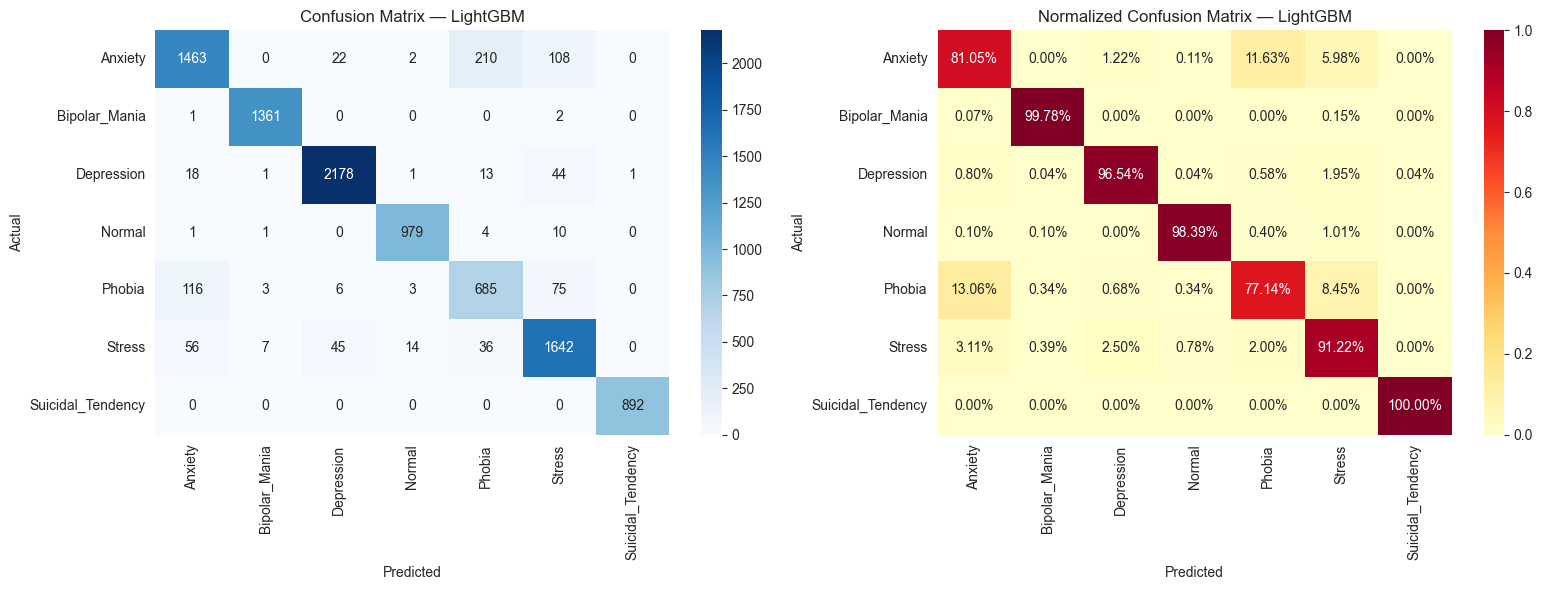


--- Runner-up evaluation: HistGradientBoosting ---
  Accuracy: 0.9204 | F1 macro: 0.9200 | F1 weighted: 0.9212

Step 17 complete.


In [ ]:
print('=' * 70)
print('STEP 17: FINAL EVALUATION ON TEST SET')
print('=' * 70)

# ─── Helper: Reconstruct model from best params ─────────────────────
class _FixedTrial:
    """Mimics an Optuna trial but returns fixed parameter values."""
    def __init__(self, params):
        self._p = params
    def suggest_int(self, name, *a, **kw):
        return self._p[name]
    def suggest_float(self, name, *a, **kw):
        return self._p[name]
    def suggest_categorical(self, name, *a, **kw):
        return self._p[name]

# ─── Build & train best model ───────────────────────────────────────
print(f'\nBest model: {best_tuned_name}')
print(f'Parameters: {tuning_results[best_tuned_name]["best_params"]}')

fixed_trial = _FixedTrial(tuning_results[best_tuned_name]['best_params'])
final_model = get_optuna_model(fixed_trial, best_tuned_name, TASK_TYPE, use_cw)

needs_sw_final = best_tuned_name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None

print(f'\nTraining on full training set ({X_train_scaled.shape[0]:,} samples)...')
if needs_sw_final:
    final_model.fit(X_train_scaled, y_train, sample_weight=sample_weight_train)
    print('Done! (with sample_weight)')
else:
    final_model.fit(X_train_scaled, y_train)
    print('Done!')

y_pred = final_model.predict(X_test_scaled)

if TASK_TYPE == 'classification':
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_wt = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    prec_wt = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_wt = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'\n--- Test Set Performance ---')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  F1 (macro)     : {f1_macro:.4f}   ← primary metric')
    print(f'  F1 (weighted)  : {f1_wt:.4f}')
    print(f'  Precision (m)  : {prec_macro:.4f}')
    print(f'  Recall (m)     : {rec_macro:.4f}')
    print(f'  Precision (wt) : {prec_wt:.4f}')
    print(f'  Recall (wt)    : {rec_wt:.4f}')

    target_names = class_names if class_names else [str(i) for i in sorted(set(y_test))]
    print(f'\n--- Full Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    # Confusion matrices
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {best_tuned_name}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
                xticklabels=target_names, yticklabels=target_names, ax=axes[1])
    axes[1].set_title(f'Normalized Confusion Matrix — {best_tuned_name}')
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    final_metrics = {
        'accuracy': round(float(acc), 4),
        'f1_macro': round(float(f1_macro), 4),
        'f1_weighted': round(float(f1_wt), 4),
        'precision_macro': round(float(prec_macro), 4),
        'recall_macro': round(float(rec_macro), 4),
        'precision_weighted': round(float(prec_wt), 4),
        'recall_weighted': round(float(rec_wt), 4)
    }

else:  # regression
    mse_val = mean_squared_error(y_test, y_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    print(f'\n--- Test Set Performance ---')
    print(f'  MSE  : {mse_val:.4f}')
    print(f'  RMSE : {rmse_val:.4f}')
    print(f'  MAE  : {mae_val:.4f}')
    print(f'  R2   : {r2_val:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'Actual vs Predicted — {best_tuned_name}')

    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].axvline(x=0, color='red', linestyle='--')
    axes[1].set_xlabel('Residual')
    axes[1].set_title('Residual Distribution')

    plt.tight_layout()
    plt.show()

    final_metrics = {
        'mse': round(float(mse_val), 4),
        'rmse': round(float(rmse_val), 4),
        'mae': round(float(mae_val), 4),
        'r2': round(float(r2_val), 4)
    }

# ─── Also evaluate runner-up (if exists) ────────────────────────────
runner_up_names = [name for name, _ in top_models if name != best_tuned_name]
if runner_up_names:
    ru_name = runner_up_names[0]
    print(f'\n--- Runner-up evaluation: {ru_name} ---')
    fixed_trial_ru = _FixedTrial(tuning_results[ru_name]['best_params'])
    ru_model = get_optuna_model(fixed_trial_ru, ru_name, TASK_TYPE, use_cw)

    needs_sw_ru = ru_name in MODELS_NEEDING_SAMPLE_WEIGHT and sample_weight_train is not None
    if needs_sw_ru:
        ru_model.fit(X_train_scaled, y_train, sample_weight=sample_weight_train)
    else:
        ru_model.fit(X_train_scaled, y_train)

    y_pred_ru = ru_model.predict(X_test_scaled)

    if TASK_TYPE == 'classification':
        acc_ru = accuracy_score(y_test, y_pred_ru)
        f1m_ru = f1_score(y_test, y_pred_ru, average='macro', zero_division=0)
        f1w_ru = f1_score(y_test, y_pred_ru, average='weighted', zero_division=0)
        print(f'  Accuracy: {acc_ru:.4f} | F1 macro: {f1m_ru:.4f} | F1 weighted: {f1w_ru:.4f}')
    else:
        rmse_ru = np.sqrt(mean_squared_error(y_test, y_pred_ru))
        r2_ru = r2_score(y_test, y_pred_ru)
        print(f'  RMSE: {rmse_ru:.4f} | R2: {r2_ru:.4f}')

PIPELINE_STATE['final_evaluation'] = {
    'best_model': best_tuned_name,
    'metrics': final_metrics
}
print(f'\nStep 17 complete.')

## Step 18 — Save All Artifacts
Save the trained model, scaler, label encoder, and full pipeline state to disk.

Each run saves to a **unique folder**: `pipeline_output/{ModelName}_{ddmmyyyy}_{hhmmss}/`
so previous runs are never overwritten.

In [ ]:
print('=' * 70)
print('STEP 18: SAVE ARTIFACTS')
print('=' * 70)

# ─── Dynamic folder: {model_name}_{ddmmyyyy}_{hhmmss} ───────────────
now = datetime.now()
model_name_clean = best_tuned_name.replace(' ', '_').replace('(', '').replace(')', '')
folder_name = f'{model_name_clean}_{now.strftime("%d%m%Y")}_{now.strftime("%H%M%S")}'
OUTPUT_DIR = os.path.join('pipeline_output', folder_name)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'\n  Output folder: {OUTPUT_DIR}/')

# ─── Helper: make JSON-serializable ─────────────────────────────────
def _make_serializable(obj):
    if isinstance(obj, dict):
        return {k: _make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_make_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj

# ─── Save model ─────────────────────────────────────────────────────
model_path = os.path.join(OUTPUT_DIR, 'best_model.joblib')
joblib.dump(final_model, model_path)
print(f'  Model saved        : {model_path}')

# ─── Save scaler ────────────────────────────────────────────────────
scaler_path = os.path.join(OUTPUT_DIR, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f'  Scaler saved       : {scaler_path}')

# ─── Save label encoder (classification only) ───────────────────────
if TASK_TYPE == 'classification' and le is not None:
    le_path = os.path.join(OUTPUT_DIR, 'label_encoder.joblib')
    joblib.dump(le, le_path)
    print(f'  Label encoder saved: {le_path}')

# ─── Save outlier transformers (for inference reproducibility) ───────
if 'outlier_transformers' in dir():
    ot_path = os.path.join(OUTPUT_DIR, 'outlier_transformers.joblib')
    joblib.dump(outlier_transformers, ot_path)
    print(f'  Outlier transforms : {ot_path}')

# ─── Save encoding artifacts (for inference reproducibility) ─────────
if 'encoding_artifacts' in dir():
    ea_path = os.path.join(OUTPUT_DIR, 'encoding_artifacts.joblib')
    joblib.dump(encoding_artifacts, ea_path)
    print(f'  Encoding artifacts : {ea_path}')

# ─── Save feature names (column order for inference) ─────────────────
feat_path = os.path.join(OUTPUT_DIR, 'feature_names.json')
with open(feat_path, 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, indent=2)
print(f'  Feature names      : {feat_path}')

# ─── Save pipeline state JSON ───────────────────────────────────────
state_path = os.path.join(OUTPUT_DIR, 'pipeline_state.json')
with open(state_path, 'w', encoding='utf-8') as f:
    json.dump(_make_serializable(PIPELINE_STATE), f, indent=2, default=str)
print(f'  Pipeline state     : {state_path}')

# ─── Save model metadata ────────────────────────────────────────────
metadata = {
    'best_model_name': best_tuned_name,
    'best_params': tuning_results[best_tuned_name]['best_params'],
    'cv_score': tuning_results[best_tuned_name]['best_score'],
    'cv_scoring': scoring,
    'test_metrics': final_metrics,
    'task_type': TASK_TYPE,
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'class_names': class_names,
    'scaler': scaler_name,
    'n_training_samples': int(X_train_scaled.shape[0]),
    'n_test_samples': int(X_test_scaled.shape[0]),
    'random_seed': RANDOM_SEED,
    'balance_strategy': BALANCE_STRATEGY,
    'used_sample_weight': best_tuned_name in MODELS_NEEDING_SAMPLE_WEIGHT,
    'saved_at': now.strftime('%d-%m-%Y %H:%M:%S')
}
metadata_path = os.path.join(OUTPUT_DIR, 'model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(_make_serializable(metadata), f, indent=2, default=str)
print(f'  Model metadata     : {metadata_path}')

# ─── Final Summary ──────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'PIPELINE COMPLETE')
print(f'{"=" * 70}')
data_info = PIPELINE_STATE.get('data_loading', {})
print(f'\n  Data       : {FILE_PATH} ({data_info.get("rows", "?"):,} rows)')
print(f'  Task       : {TASK_TYPE}')
print(f'  Features   : {len(feature_names)}')
print(f'  Best model : {best_tuned_name}')
print(f'  Scoring    : {scoring}')
print(f'  Metrics    : {final_metrics}')
print(f'\n  Artifacts saved to: {OUTPUT_DIR}/')
print(f'    best_model.joblib')
print(f'    scaler.joblib')
if TASK_TYPE == 'classification':
    print(f'    label_encoder.joblib')
print(f'    outlier_transformers.joblib')
print(f'    encoding_artifacts.joblib')
print(f'    feature_names.json')
print(f'    pipeline_state.json')
print(f'    model_metadata.json')
print(f'\n  Pipeline finished successfully!')

STEP 18: SAVE ARTIFACTS

  Output folder: pipeline_output\LightGBM_13032026_110356/
  Model saved        : pipeline_output\LightGBM_13032026_110356\best_model.joblib
  Scaler saved       : pipeline_output\LightGBM_13032026_110356\scaler.joblib
  Label encoder saved: pipeline_output\LightGBM_13032026_110356\label_encoder.joblib
  Outlier transforms : pipeline_output\LightGBM_13032026_110356\outlier_transformers.joblib
  Encoding artifacts : pipeline_output\LightGBM_13032026_110356\encoding_artifacts.joblib
  Feature names      : pipeline_output\LightGBM_13032026_110356\feature_names.json
  Pipeline state     : pipeline_output\LightGBM_13032026_110356\pipeline_state.json
  Model metadata     : pipeline_output\LightGBM_13032026_110356\model_metadata.json

PIPELINE COMPLETE

  Data       : data\mental_health_synthetic_dataset_with_normal.csv (50,000 rows)
  Task       : classification
  Features   : 43
  Best model : LightGBM
  Scoring    : f1_macro
  Metrics    : {'accuracy': 0.92, 'f1_ma